# Telco Customer Churn Project

# Table of Contents
1. [Introduction](#1.-Introduction)
   - [1.1 What Is Customer Churn?](#1.1-What-Is-Customer-Churn)
   - [1.2 Dataset Overview](#1.2-Data-Overview)
   - [1.3 Project Scope](#1.3-Project-Scope)
2. [Overall Churn Overview](#2.-Overall-Churn-Overview)
   - [2.1 Churn Rate](#2.1-Churn-Rate)
   - [2.2 Churn by City](#2.2-Churn-by-City)
   - [2.3 Churn by Category](#2.3-Churn-by-Category)
   - [2.4 Churn by Contract Type](#2.3-Churn-by-Contract-Type)
4. [Data Analysis](#3.-Data-Analysis)
   - [3.1 Demographics Data](#2.1-Demographics-Data)
   - [3.2 Geographical Data](#2.2-Geographical-Data)
   - [3.3 Behavioral Data](#2.3-Behavioral-Data)
   - [3.4 Churn Status Data](#2.4-Churn-Status-Data)

# 1. Introduction

## 1.1 Defining Customer Churn

The definition of customer is ["the number of existing customers lost, for any reason at all, over a given period of time."](https://www.ibm.com/think/topics/customer-churn). Knowing how many customers churned this month/quarter, and even who those customers are, helps the company understand where they went wrong and what changes need to be made to improve customer retention.

Unlike businesses that rely on one-time sales, SaaS businesses rely on monthly recurring revenues from subscriptions which makes customer churn an important metric for these types of businessnes. They need to know if their customers are churning, when and why, in order to be in control of their revenue. A SaaS company has to have a base of recurring customers or else it won’t be able to meet certain obligations, let alone make a profit.

## 1.2 Dataset Overview

The Telco dataset was downloaded directly from [IBM](https://accelerator.ca.analytics.ibm.com/bi/?perspective=authoring&pathRef=.public_folders%2FIBM%2BAccelerator%2BCatalog%2FContent%2FDAT00148&id=i9710CF25EF75468D95FFFC7D57D45204&objRef=i9710CF25EF75468D95FFFC7D57D45204&action=run&format=HTML&cmPropStr=%7B%22id%22%3A%22i9710CF25EF75468D95FFFC7D57D45204%22%2C%22type%22%3A%22reportView%22%2C%22defaultName%22%3A%22DAT00148%22%2C%22permissions%22%3A%5B%22execute%22%2C%22read%22%2C%22traverse%22%5D%7D). The data focuses on Telco's customers who live in California, United States, and it contains churn data for Q3. To get a detailed description of the data and each column in the dataset please refer to this [kaggle link](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset/data).

For this project, I chose to use SQL Server as my relational database management system. I'm going to pull out the first five records of each table to give an idea of how each table looks like:

**Table #1: demographics** - contains data about customer's gender, age, if they're under 30, if they're a senior citizen, if they're married, if they have dependents and the number of dependents.
   
Primary key: Customer_ID

```sql
SELECT 
    TOP 5 * 
FROM demographics;
```

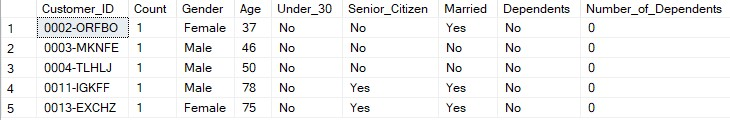

**Table #2: location** - contains data about country, state, city, zip code and coordinates (latitude/longtitude).
   
* Primary key: Location_ID
* Foreign key: Customer_ID

```sql
SELECT 
    TOP 5 * 
FROM location;
```

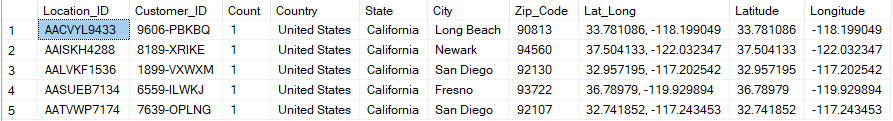

**Table #3: population** - contains data about each zip code's population size.
* Primary key: ID
* Foreign Key: Zip_Code 

```sql
SELECT 
    TOP 5 * 
FROM population;
```

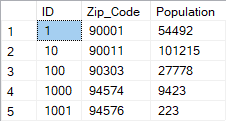

**Table #4: services** - contains data related to the company's services, internet/phone/streaming/backup services, monthly/total charges, contract type, offer type, whether a customer uses paperless/paper billing, payment method, tenure length etc. 
* Primary key: Service_ID
* Foreign key: Customer_ID

```sql
SELECT 
    TOP 5 *
FROM customer_services;
```

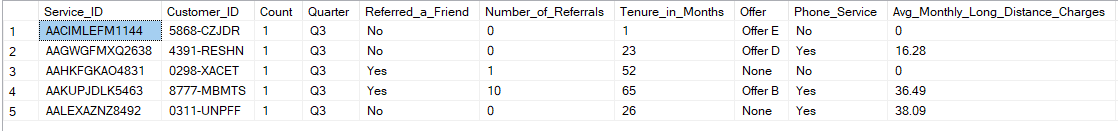

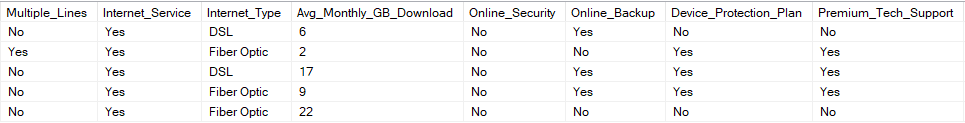

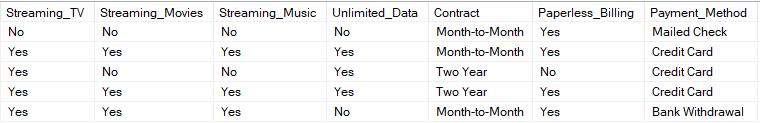

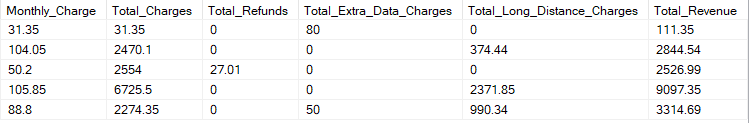

**Table #5: churn_status** - contains data such as customer churn status, satisfaction score, churn score, CLTV, churn category and churn reason. 

- Primary key: Status_ID
- Foreign key: Customer_ID

```sql
SELECT 
    TOP 5 * 
FROM churn_status;
```

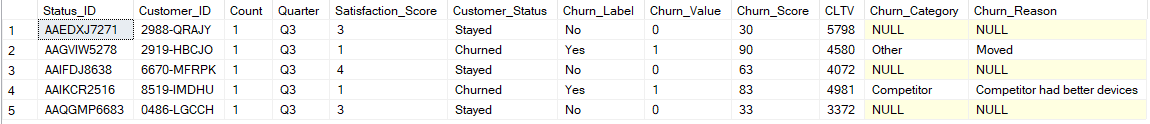

## 1.3 Project Scope

This project attempts to identify which customer characteristics and behaviors are most associated with churn. To analyze the data, I will use SQL Server as my relational database management system, while Tableau will serve as my tool for creating visualizations.

# 2. Overall Churn Overview

In [161]:
from IPython.display import display, HTML

# 1. This CSS forces the Jupyter output area to stop restricting height
display(HTML("<style>div.output_area { height: auto !important; max-height: none !important; }</style>"))

# 2. PASTE YOUR URL BELOW between the quotes
# Note: I added the secret "no-scrollbar" settings to the end of the URL
viz_url = "https://public.tableau.com/views/ChurnDashboard_17650243498510/OverallChurnOverviewDB?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link" + "?:embed=y&:showVizHome=n&:toolbar=n"

# 3. This is where we force the display
iframe_html = f"""
<iframe src="{viz_url}" 
        width="100%" 
        height="950px" 
        frameborder="0" 
        scrolling="no" 
        style="border:none;">
</iframe>
"""

display(HTML(iframe_html))

## 2.1 KPIs

### 2.1.1 Churn Rate

Churn rate is a KPI that checks the percentage rate at which customers stop subscribing to a service. For quarterly churn, churn rate above 10% is generally considered high.

Formula used:

**Churn Rate = Customers who left during the period / Customers at the start of the period * 100**

NOTE: the customers who have 'joined' in the customer_status field are customers who have joined Telco sometime during Q3 which means they should not be included in the denominator (customers at the start of the period).

```sql
-- churn rate pct
    
SELECT
	CAST(
		100.0 * 
    		SUM(CASE WHEN churn_value = 1 THEN 1 ELSE 0 END)
    		/ SUM(CASE WHEN customer_status IN ('Stayed', 'Churned') THEN 1 ELSE 0 END) 
    		 AS DECIMAL(5,2)
		 ) AS churn_rate_pct
FROM status;
```

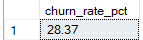

Telco's churn rate for Q3 is approximately 28.4% which is very high. It means that Telco lost almost a 3rd of its customer base in only three months.

### 2.1.2 Net Change

Net change checks how many customers were lost during Q3. It takes the customers who joined during this quarter and deducts the churned customers leaving us with either a negative or a positive number. If the number is negative then it means Telco lost customers, and if it's positive then it means it gained customers.

Formula:

**Net Change = Customers Joined - Customers Churned**

```sql
-- net change
    
SELECT 
	SUM(CASE WHEN customer_status = 'Joined' THEN 1 ELSE 0 END)
  -	SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END)
	AS net_change
FROM status;
```


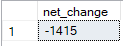

Telco's net change is -1415, indicating that the company lost 1415 customers during Q3. In other words, even if some customers joined it wasn't a number high enough to shift the net change to a positive number because the amount of customer who churned was much bigger.

### 2.1.3 QRR

QRR (quarterly recurring revenue) is a KPI that is especially useful for SaaS businesses because it shows the recurring revenue made from all subscriptions in a given quarter. To calculate it, it's better to use the monthly_charge field instead of the total_revenue field because the latter doesn't include only payments that are recurring, and we don't want that (we only want recurring payments).

```sql
-- total quarterly recurring revenue
-- Formula: Total Monthly Charges * 3

SELECT 
	ROUND(
        SUM(monthly_charge *3)
        ,1)
    AS QRR
FROM services;
```

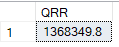

**Telco's total QRR is approximately $1.37M.**

NOTE: This formula provides an estimated QRR, assuming monthly charges remained stable across Q3 and that all customers were active for the full quarter.

### 2.1.4 ARPU

ARPU (Average Revenue Per User) is another KPI that is useful for SaaS/Telecom businesses. It shows another angle of the company's revenue, this time focusing on the average revenue that a customer generates in a given time period. In Telco's case, we are going to calculate the quarterly ARPU by dividing the total revenue generated in Q3 by the number of active customers in Q3 (by "active" I mean people who generated any revenue during Q3 at all).

Formula:

**Total Revenue in Q3 / Number of Active Customers in Q3**

```sql
-- total quarterly recurring revenue

SELECT
	ROUND(
		SUM(total_revenue) / COUNT(*)
	,1) AS ARPU
FROM services;
```

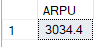

## 2.2 Churn Rate by City

Let's calculate the churn rate by city.

*NOTE: for meaningful insights I chose to only use cities with a customer base of at least 50. This way the sample size is not too small.*

```sql
-- churn by city
    
SELECT
    loc.city,
    CAST(
        100.0 * SUM(CASE WHEN stat.churn_value = 1 THEN 1 ELSE 0 END)
        / COUNT(*)
        AS DECIMAL(5,1)
    ) AS churn_rate_pct
FROM status AS stat
JOIN location AS loc
ON stat.customer_id = loc.customer_id
WHERE stat.customer_status IN ('Stayed', 'Churned')
GROUP BY loc.city
HAVING COUNT(*) >= 50
ORDER BY churn_rate_pct DESC;
```

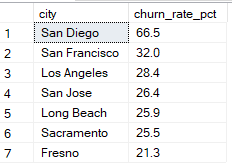

**San Diego is leading with a churn rate of ≈67% which is more than double that of the other cities ranging from 21-32%.**

## 2.3 Churn by Category

```sql
-- pct of total churn by category

SELECT
	churn_category,
	CAST(
		100.0 *
		COUNT(*) / (SELECT COUNT(*) FROM status WHERE churn_value = 1)
		AS DECIMAL(5,1)
	) AS pct_of_total_churn
FROM status
WHERE churn_value = 1
GROUP BY churn_category
ORDER BY pct_of_total_churn DESC;
```

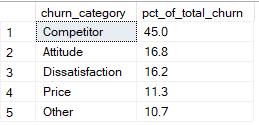

**Nearly half of churned customers (45%) cited competition as the reason for leaving.** This shows that Telco has strong competitors that may have more appealing offers that pull in customers.

## 2.4 Churn Rate by Contract Type

```sql
-- churn rate by contract type

SELECT
	contract,
	CAST(
		100.0 *
			SUM(CASE WHEN churn_value = 1 THEN 1 ELSE 0 END) 
			/ COUNT(*) 
		AS DECIMAL(5,1)
	) AS churn_rate_pct
FROM status stat
JOIN services ser
ON stat.Customer_ID = ser.Customer_ID
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY contract
ORDER BY churn_rate_pct DESC;
```

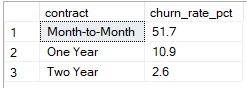

The Month-to-Month contract is leading with the highest churn rate of ≈52%, followed by the One-Year contract with 11% and the Two-Year contract with ≈3%.

## 2.5 Churn Rate by Offer

Occassionally, telecommunications companies would make promotional offer that include bundles, discounts with additional products/services that better appeals the customer. Telco offers five different offers: Offer A, Offer B, Offer C, Offer D and Offer E. The dataset also includes customers who did not receive any offer for whatever reason.

```sql
-- churn rate by offer type

SELECT 
	Offer,
	COUNT(*) AS customer_count,
	SUM(CASE WHEN churn_value = 1 THEN 1 ELSE 0 END) AS churn_count,
	CAST(
		100.0 * SUM(CASE WHEN churn_value = 1 THEN 1 ELSE 0 END) 
		/ COUNT(*) AS DECIMAL(5,1)
	) AS churn_rate_pct
FROM services AS serv
JOIN status AS stat
ON serv.Customer_ID = stat.Customer_ID
WHERE stat.customer_status IN ('Stayed', 'Churned')
GROUP BY Offer
ORDER BY churn_rate_pct DESC;
```

##### 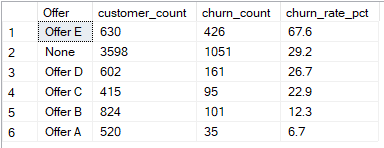

**Customers with Offer E tend to churn the most (68%).**

Even though the churn count is the highest for customers who received no offer (1051), this does not mean they are more likely to churn. This is because the high raw churn numbers are regarded to the fact that the number of customers who did not receive any offer is much higher (3598), but the actual churn rate is only 27%.

## 2.6 Churn Rate by Tenure

```sql
-- Churn Rate by Tenure

WITH tenure_group_cte AS
(
SELECT
	CASE
          WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
          WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
          WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
          WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
          WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
          ELSE '61-72'
	END AS tenure_order,
    CASE
          WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
          WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
          WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
          WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
          WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
          ELSE '61-72'
    END AS tenure_group, customer_status
FROM Services AS serv
JOIN Status AS stat
ON serv.Customer_ID = stat.Customer_ID
)
SELECT 
	tenure_group,
	CAST(100.0 * SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) /
	COUNT(*) AS DECIMAL(5,1)) AS churn_rate
FROM tenure_group_cte
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY tenure_group, tenure_order
ORDER by tenure_order;
```
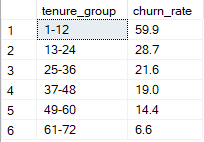

**The shorter the tenure the higher the churn rate.** 

## 2.7 Churn Rate by Monthly Charge Tiers

```sql
-- Churn rate by monthly charge tiers

WITH q AS 
(
    SELECT
		serv.Customer_ID,
		serv.contract,
		serv.monthly_charge,
		stat.customer_status,
		PERCENTILE_CONT(0.25) -- generate the Q1 and Q3 values
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q1,
		PERCENTILE_CONT(0.75)
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q3
	FROM services AS serv
	JOIN status AS stat
	ON serv.Customer_ID = stat.Customer_ID
)
	SELECT
	  CASE -- create bins for low, mid and high monthly charges
		WHEN monthly_charge < q1 THEN 'low'
		WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
		ELSE 'high'
	  END AS mth_charges_group,
	  CAST(100.0 * SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) / COUNT(*) AS DECIMAL(5,1)) AS churn_rate
	FROM q
	GROUP BY
	  CASE
		WHEN monthly_charge < q1 THEN 'low'
		WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
		ELSE 'high'
	  END
	ORDER BY churn_rate DESC;
```
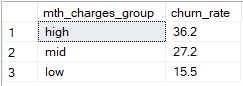

**High monthly charge customers are higher-risk in terms of churn since such customers have the highest churn rate.**

## 2.8 Churn by Internet Type

```sql
SELECT
	Internet_Type,
	CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) 
	AS DECIMAL (5,1)) AS churn_rate
FROM services
JOIN status 
ON services.Customer_ID = status.Customer_ID
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY Internet_Type
ORDER BY churn_rate DESC;
```
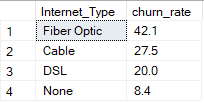

**Fiber Optic customers show the highest churn (42.1%), indicating a key segment to target for retention efforts, whereas customers without internet service have the lowest churn (8.4%).**

# 3. Data Analysis

## 3.1 Demographics Data

In this part, I will focus on the customer's demographic data:

* Gender
* Age
* Marital Status
* Dependents (children or anyone who depends on the house owner for financial support)

I will try to find out whether the above demographic data reveals any trends or patterns that can help us define who are the churners and what are the potential causes of customer churn.

### 3.1.1 Gender

```sql
-- churn count and churn rate by gender

SELECT 
    gender,
    COUNT(CASE WHEN churn_value=1 THEN 1 END) 
		AS churn_count,
    CAST(ROUND(100.0 *
		COUNT(CASE WHEN churn_value=1 THEN 1 END) 
		/ COUNT(*), 1) AS DECIMAL (5,1)) 
        AS churn_rate_pct
FROM demographics as d
JOIN status as s
ON d.customer_id=s.customer_id
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY gender;
```

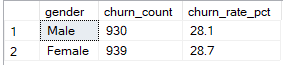

**Churn rates and churn counts are very similar across genders, with females showing a slightly higher rate (28.1% vs 28.7%).**

### 3.1.2 Age
Now, let's see the churn rate by age. To do this, I will first create age groups and then I will use a CTE to retrieve the churn count for each age group:

```sql
-- Churn by age group

WITH age_group_cte AS (
    SELECT 
        CASE 
            WHEN d.age < 18 THEN 'Under 18'
            WHEN d.age BETWEEN 18 AND 24 THEN '18–24'
            WHEN d.age BETWEEN 25 AND 34 THEN '25–34'
            WHEN d.age BETWEEN 35 AND 44 THEN '35–44'
            WHEN d.age BETWEEN 45 AND 54 THEN '45–54'
            WHEN d.age BETWEEN 55 AND 64 THEN '55–64'
            WHEN d.age >= 65 THEN '65+'
        END AS age_group,
        s.churn_value
    FROM demographics AS d
    JOIN status AS s 
        ON d.customer_id = s.customer_id
    WHERE s.customer_status IN ('Stayed', 'Churned')
)
SELECT 
    age_group,
    COUNT(CASE WHEN ag.churn_value = 1 THEN 1 END) AS churned_count,
    CAST(ROUND(
        100.0 * COUNT(CASE WHEN ag.churn_value = 1 THEN 1 END) / 
        COUNT(*), 1) AS DECIMAL(5,1)) AS churn_rate_pct
FROM age_group_cte AS ag
GROUP BY age_group
ORDER BY age_group;
```

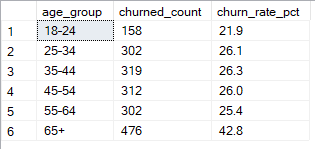

**Churn rates remain fairly consistent across most age groups (≈25-26%), but increase noticeably among customers aged 65 and above (≈43%).**

In [10]:
%%HTML
<div class='tableauPlaceholder' id='viz1767343651878' style='position: relative'><noscript><a href='#'><img alt='Churn Rate by Age Group (db) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ch&#47;ChurnRatebyAgeGroupdb&#47;ChurnRatebyAgeGroupdb&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='ChurnRatebyAgeGroupdb&#47;ChurnRatebyAgeGroupdb' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ch&#47;ChurnRatebyAgeGroupdb&#47;ChurnRatebyAgeGroupdb&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1767343651878');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='500px';vizElement.style.height='577px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='500px';vizElement.style.height='577px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

*Does the length of the tenure affect the churn rate for senior customers?*

```sql
-- avg. tenure for customers aged 65 and below vs. customers aged 65 and above

SELECT 
  AVG(CASE WHEN age > 65 THEN tenure_in_months END) as avg_tenure_above_65,
  AVG(CASE WHEN age < 65 THEN tenure_in_months END) as avg_tenure_below_65
FROM services as serv
JOIN demographics as demo
  ON serv.Customer_ID = demo.Customer_ID;
```

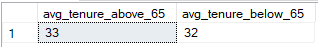

**The average tenure is similar across both age groups which means that tenure is likely not a factor here.**

```sql
-- avg. tenure by age group

WITH age_groups AS
(
SELECT CASE WHEN age <18 THEN 'Under 18' 
    WHEN age BETWEEN 18 AND 24 THEN '18–24' 
    WHEN age BETWEEN 25 AND 34 THEN '25–34' 
    WHEN age BETWEEN 35 AND 44 THEN '35–44' 
    WHEN age BETWEEN 45 AND 54 THEN '45–54' 
    WHEN age BETWEEN 55 AND 64 THEN '55–64' 
    WHEN age>=65 THEN '65+' 
END as age_group, Tenure_in_Months
FROM demographics AS demo
JOIN services AS serv
ON demo.Customer_ID = serv.Customer_ID
)
SELECT
age_group,
AVG(tenure_in_months) AS avg_tenure
FROM age_groups
GROUP BY age_group;
```

**Average tenure is consistent across all age groups (≈30–33 months), indicating no clear relationship between age and tenure.**

*Does internet type directly impact churn in senior customers?*

```sql
-- churn rate by internet type for senior customers (65+)

SELECT
    serv.internet_type,
    COUNT(CASE WHEN stat.churn_value = 1 THEN 1 END) AS churn_count_seniors,
	COUNT(*) AS senior_customers,
    CAST(100.0 * COUNT(CASE WHEN stat.churn_value = 1 THEN 1 END) / COUNT(*) AS DECIMAL(5,2)) AS churn_rate_seniors
FROM demographics AS demo
JOIN services AS serv
	ON demo.Customer_ID = serv.Customer_ID
JOIN status AS stat
	ON serv.Customer_ID = stat.Customer_ID
WHERE age >= 65
	AND internet_type <> 'None'
GROUP BY serv.internet_type
ORDER BY churn_rate_seniors DESC;
```

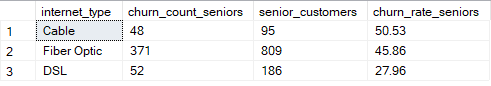

**Senior Fiber optic users have elevated churn (46%). Cable may also be high (50%), but the small sample size limits confidence.**

- Cable shows the highest churn rate (50%), but the sample size is small (n=95), so this result is less stable.

- Fiber Optic has a high churn rate as well (46%) with a large sample (n=809), making this trend more reliable.

- DSL seniors show a lower churn rate (~28%) with a moderate sample size (n=186).

Let's check the churn rate by internet type for all customers (not just seniors). This will allow us to understand how churn rate looks like for cable internet for all Telco's customers in general.

```sql
-- churn rate by internet type (all customers)

SELECT
    serv.internet_type,
    COUNT(CASE WHEN stat.churn_value = 1 THEN 1 END) AS churn_count_seniors,
	COUNT(*) AS senior_customers,
    CAST(100.0 * COUNT(CASE WHEN stat.churn_value = 1 THEN 1 END) / COUNT(*) AS DECIMAL(5,2)) AS churn_rate_seniors
FROM demographics AS demo
JOIN services AS serv
	ON demo.Customer_ID = serv.Customer_ID
JOIN status AS stat
	ON serv.Customer_ID = stat.Customer_ID
WHERE age >= 65
	AND internet_type <> 'None'
GROUP BY serv.internet_type
ORDER BY churn_rate_seniors DESC;
```

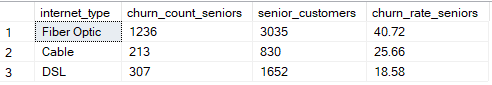

**Cable internet churn rate is much lower when looking at the entire customer base: Cable churn rate for seniors is around 50% which is double that of the entire customer base (26%).** 

Although Cable seniors represent a small sample (n=95), the jump is still notable and may indicate specific service, pricing, or usability issues that disproportionately impact older cable customers.

Cable seniors may be on older legacy plans with higher pricing or outdated service bundles. This may cause higher churn rate among such customers. We can check what offers these customers received and see if any of them did not receive an offer which may suggest they have been on an outdated plan for a while:

```sql
-- senior cable customer count by offer

SELECT 
    Offer,
    COUNT(*) AS offer_count,
    SUM(COUNT(*)) OVER () AS total_senior_cable_customers
FROM services AS serv
JOIN demographics AS demo
    ON serv.Customer_ID = demo.Customer_ID
JOIN status AS stat
    ON serv.Customer_ID = stat.Customer_ID
WHERE age >= 65 
  AND Internet_Type = 'Cable'
GROUP BY Offer
ORDER BY offer_count DESC;
```
```sql
-- Churned senior cable customer count by offer

SELECT 
    Offer,
    COUNT(*) AS offer_count,
    SUM(COUNT(*)) OVER () AS total_senior_cable_customers
FROM services AS serv
JOIN demographics AS demo
    ON serv.Customer_ID = demo.Customer_ID
JOIN status AS stat
    ON serv.Customer_ID = stat.Customer_ID
WHERE age >= 65 
  AND Internet_Type = 'Cable'
  AND churn_value = 1
GROUP BY Offer
ORDER BY offer_count DESC;
```

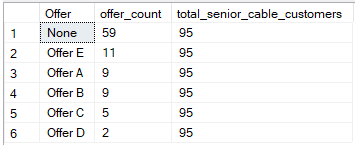

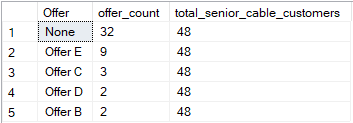

**Most of the senior customers who have cable internet did not receive any promotional offer which may means that they were on outdated plans that included no discounts and higher prices.** 

Let's check the average monthly charges for such customers:

```sql
-- avg monthly charges by internet type

SELECT 
	Internet_Type,
	ROUND(AVG(monthly_charge),1) AS avg_monthly_charges
FROM services
GROUP BY Internet_Type
ORDER BY AVG(monthly_charge) DESC;
```
```sql
-- avg monthly charges for seniors

SELECT 
	Internet_Type,
	ROUND(AVG(monthly_charge),1) AS avg_monthly_charges
FROM services AS serv
JOIN demographics AS demo
ON serv.Customer_ID = demo.Customer_ID
WHERE age >= 65
AND internet_type <> 'None'
GROUP BY Internet_Type
ORDER BY AVG(monthly_charge) DESC;
```

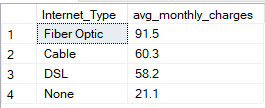

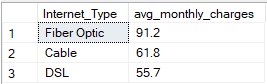

**The highest average monthly charges are for Fiber optic, not for cable.** However, it's important to note that the above doesn't accurately represent internet prices but is only an estimate since our data does not include a separate field for only internet prices.

**Even though we cannot tell for sure if the churned cable senior users are paying more for their cable internet, the results above about the offers received by customers still suggest that such customers may have been on outdated plans which could have caused their high churn rate.**

```sql
-- pct of senior customers with paperless billing vs. paper billing

SELECT
    serv.Paperless_Billing,
    COUNT(*) AS customer_count,
    CAST(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () 
        AS DECIMAL(5,2)
    ) AS pct_of_seniors
FROM demographics AS demo
JOIN services AS serv
    ON demo.Customer_ID = serv.Customer_ID
WHERE age >= 65
GROUP BY serv.Paperless_Billing;
```

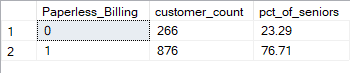

**77% of senior customers use paperless billing.** 

Let's check the churn rate for each billing type in customers who are 65 and above:

```sql
-- churn by billing type for customers aged 65 and above

SELECT 
    Paperless_Billing,
    COUNT(CASE WHEN stat.Churn_Value = 1 THEN 1 END) AS churned_seniors,
    CAST(100.0 * COUNT(CASE WHEN stat.Churn_Value = 1 THEN 1 END) / COUNT(*) AS DECIMAL(5,2)) AS churn_rate_pct
FROM services AS serv
JOIN demographics AS demo
    ON serv.Customer_ID = demo.Customer_ID
JOIN status AS stat
    ON serv.Customer_ID = stat.Customer_ID
WHERE age >= 65
GROUP BY Paperless_Billing
ORDER BY Paperless_Billing;
```

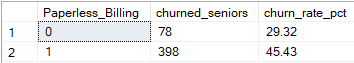

**Senior customers using paperless billing have a higher churn rate (45%) compared to those with paper bills (29%).**

However, for the results above to be meaninful we need to first check the billing type distribution for all customers. If we find that most of the customers use paperless billing then we cannot conclude that paperless billing is a factor in senior customer churn.

```sql
-- pct of customers with paperless billing vs. paper billing

SELECT
    serv.Paperless_Billing,
    COUNT(*) AS customer_count,
    CAST(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER () 
        AS DECIMAL(5,2)
    ) AS pct_of_customers
FROM demographics AS demo
JOIN services AS serv
    ON demo.Customer_ID = serv.Customer_ID
GROUP BY serv.Paperless_Billing;
```

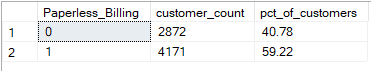

**Among customers aged 65 and above, paperless billing is associated with higher churn rates compared to paper billing. However, since paperless billing is the most commonly used billing method, this association alone does not confirm that digital billing is the underlying driver of churn among senior customers. Further qualitative analysis, such as customer surveys, could help determine whether usability or satisfaction issues contribute to this pattern.**

```sql
-- pct of customers by payment method
SELECT 
    Payment_Method,
    CAST(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER ()
        AS DECIMAL(5,1)
    ) AS pct_customers
FROM services AS serv
JOIN demographics AS demo
    ON serv.Customer_ID = demo.Customer_ID
JOIN status AS stat
    ON serv.Customer_ID = stat.Customer_ID
GROUP BY Payment_Method
ORDER BY pct_customers DESC;
```

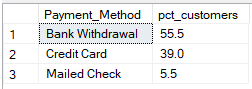

**The majority of customers use bank withdrawal as their payment method (56%).**

```sql
-- pct of senior customers by method method

SELECT 
	Payment_Method, 
	CAST(
		100.0 * COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () 
		AS DECIMAL(5,1)
   ) AS pct_seniors
FROM services AS serv
JOIN demographics AS demo
    ON serv.Customer_ID = demo.Customer_ID
JOIN status AS stat
    ON serv.Customer_ID = stat.Customer_ID
WHERE age >= 65
GROUP BY Payment_Method
ORDER BY pct_seniors DESC;
```

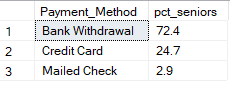

**The majority of senior customers also use bank withdrawal as their payment method. This is likely because the majority of the customers use this method so these results don't tell us much, and we cannot consider payment method as a factor in senior customer churn.**

### 3.1.3 Marital Status & Dependents

NOTE: each customer, whether married or not, can have or not have dependents. In this dataset, the 'dependents' column refers to someone who lives with the customer in the same house, but it doesn't necessarily have to be their children but rather someone who is financially supported by them.

```sql
-- churn by marital status 

SELECT 
    CASE WHEN married=0 THEN 'No' ELSE 'Yes' END AS Married,
    COUNT(*) AS customer_count,
	SUM(CASE WHEN churn_value = 1 THEN 1 ELSE 0 END) AS churn_count,
    CAST(100.0 * 
        COUNT(CASE WHEN churn_value=1 THEN 1 END) 
		/ COUNT(*) AS DECIMAL (5,1)
	) AS churn_rate_percentage
FROM demographics AS d
JOIN status AS s
    ON d.customer_id = s.customer_id
GROUP BY married;
```

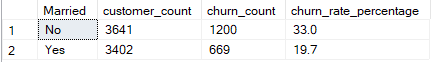

**Overall, non-married customers show a higher churn rate (33%) than married ones (20%).**

```sql
-- churn rate for non-married customers w/ dependents vs. w/o dependents

SELECT Dependents, 
	COUNT(*) AS total_customers, 
	SUM(CASE WHEN churn_value = 1 THEN 1 END) AS churned,
	CAST(
		100.0 * SUM(CASE WHEN churn_value = 1 THEN 1 END) / COUNT(*) 
		AS DECIMAL(5,1)
	) AS churn_rate 
FROM demographics AS demo
JOIN status AS stat 
	ON demo.customer_id = stat.customer_id 
WHERE Married = 0 
GROUP BY Dependents;
```

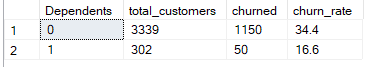

**Unmarried customers with no dependents tend to churn more (34%) than the ones with dependents (17%)**. 

This is likely because customers with no dependents are often more flexible because they do not need to ensure constant internet/phone connectivity for family members and they can afford to move apartments more often. 

Customers with no dependents also tend to not committ to low-term contracts like a one-year or a two-year contract, and tend to stick to a contract that is easier to get out of (like an MTM contract).

```sql
-- pct of customers by contract type for non-married customers w/o dependents

SELECT
    contract,
	COUNT(*) AS total_customers,
    CAST(
		100.0 * COUNT(*) / SUM(COUNT(*)) OVER()
		AS DECIMAL(5,1)
	) AS pct_of_group
FROM services AS serv
JOIN demographics AS demo 
    ON serv.customer_id = demo.customer_id
WHERE demo.Married = 0
  AND demo.Dependents = 0
GROUP BY contract;
```

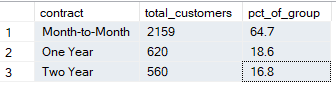

**Most of the unmarried customers with no dependents are subscribed to the MTM contract (64%).** Since MTM customers tend to churn more (see 2.4), we can say that unmarried customers with no dependents are more likely to churn since most of them are MTM customers. 

The above results are true for all customers with no dependents (not only unmarried ones):

```sql
-- pct of customers w/o dependents by contract type

SELECT
    contract,
	COUNT(*) AS total_customers,
    CAST(
		100.0 * COUNT(*) / SUM(COUNT(*)) OVER()
		AS DECIMAL(5,1)
	) AS pct_of_group
FROM services AS serv
JOIN demographics AS demo 
    ON serv.customer_id = demo.customer_id
WHERE demo.Dependents = 0
GROUP BY contract;
```

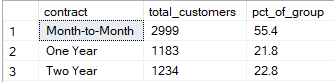

**Customers with no dependents tend to be subscribed to the MTM contract.**

*Do most unmarried customers with no dependents use fiber internet?*

```sql
-- pct of unmarried customers w/o dependents by internet type

SELECT
    Internet_Type,
	COUNT(*) AS total_customers,
    CAST(
		100.0 * COUNT(*) / SUM(COUNT(*)) OVER()
		AS DECIMAL(5,1)
	) AS pct_of_group
FROM services AS serv
JOIN demographics AS demo 
    ON serv.customer_id = demo.customer_id
WHERE demo.Dependents = 0
AND demo.Married = 0
AND serv.Internet_Service = 1
GROUP BY Internet_Type;
```

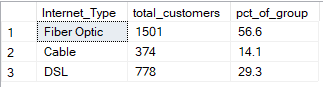

**Most of the unmarried customers w/o dependents use fiber optic (57%) which is usually more expensive.**. Even though this dataset doesn't include separate prices for the different internet types we can check average monthly charges:

```sql
-- avg monthly charges for unmarried customers with vs. without dependents

SELECT
	Dependents,
	ROUND(AVG(monthly_charge),1) AS avg_monthly_charges
FROM services AS serv
JOIN demographics AS demo 
    ON serv.customer_id = demo.customer_id
WHERE demo.Married = 0
AND serv.Internet_Service = 1
GROUP BY Dependents;
```

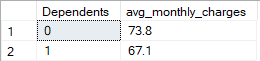

**The average monthly charges for unmarried customers w/o dependents is higher (74%) than those with dependents (67%).**

```sql
-- avg monthly charges for customers with vs. without dependents

SELECT
	Dependents,
	ROUND(AVG(monthly_charge),1) AS avg_monthly_charges
FROM services AS serv
JOIN demographics AS demo 
    ON serv.customer_id = demo.customer_id
WHERE serv.Internet_Service = 1
GROUP BY Dependents;
```

Let's check the same for all customers, not only the unmarried ones:

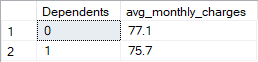

**The average monthly charges for customers w/o dependents is still a little higher (77%) than those with dependents (76%).**

The above results show that customers with no dependents, especially unmarried customers, have higher monthly charges which can potentially be the reason for their high churn rate.

*What can Telco do to minimize churn among customers with no dependents?*

-	Offer loyalty incentives for individuals living alone
-	Provide low-cost bundles targeted at single households
-	Introduce optional add-ons or discounts to increase attachment
-	Trigger early intervention for this persona (personalized offers when their usage drops)

**Customers with 0 dependents are slightly more likely to have multiple lines than customers with dependents.** This is not something we expected but it is very possible that a lot of customers with no dependents have multiple lines, whether for personal use or multiple lines for different businesses, etc.

## 3.2 Geographical Data

In this section, I will check how geographical data such as city and population size affects customer churn. Does population size matter when talking about churn? Are there cities/areas which have a higher churn rate?

Section 2.2 shows that San Diego is the city with the highest churn rate of 66%. It is followed by San Francisco with 32%. To explain this, we could check how population size affects churn rate:

### 3.2.1 Population vs. Churn

Let's check the churn by population size by summing up the population sizes for each zip code within a particular city and grouping the population size by city. For this, we will join the services table (that contain the churn_value column and the zip code) with the population table and the location table that contain the population size and cities respectively.

**Notes:** 

1. Since the location table is a row per customer table, we have to make sure we calculate the sum of population for each distinct zip code and not include the same zip code's population value twice or more (depending on the number of customers with this zip code). For that, we will create a subquery table that returns distinct city and zip code from the location table, and then, we will select city and sum(population) from that subquery table. That way, we will not have include dupes (counting the population value of the same zip code twice) but we will sum up population values that are identical if their zip codes are different.

2. To get meaningful results, we will only include cities with at least 50 customers. Including cities with 5 customers, for example, could be misleading and won't be statistically meaningful. A city can have a churn rate of 50% which is huge, but if that city has only 10 customers and 5 of them left then the results are not very telling as the sample size is way too small.

```sql
-- Step 1: aggregate population per city

WITH city_population AS (
    SELECT l.city, SUM(p.population) AS total_population
    FROM (
        SELECT DISTINCT city, zip_code
        FROM location
    ) l
    JOIN population p
        ON l.zip_code = p.zip_code
    GROUP BY l.city
),

city_churn AS (
    SELECT l.city,
           COUNT(*) AS total_customers_all, 
           COUNT(CASE WHEN s.customer_status IN ('Stayed', 'Churned') THEN 1 END) AS eligible_customers,
           COUNT(CASE WHEN s.customer_status = 'Churned' THEN 1 END) AS churn_count
    FROM location l
    JOIN status s
        ON l.customer_id = s.customer_id
    GROUP BY l.city
    HAVING COUNT(*) >= 50
)
    
SELECT cp.city,
       cp.total_population,
       cc.total_customers_all,
       cc.churn_count,
       CAST(cc.churn_count * 100.0 / NULLIF(cc.eligible_customers, 0) AS DECIMAL (5,1)) AS churn_rate
FROM city_population cp
JOIN city_churn cc
    ON cp.city = cc.city
WHERE cp.city <> 'Los Angeles'
ORDER BY total_population DESC;
```

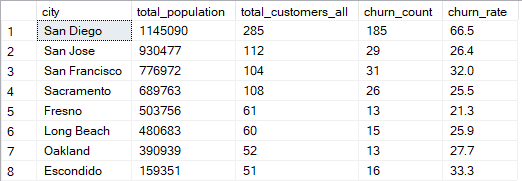

In [147]:
%%HTML
<div class='tableauPlaceholder' id='viz1765368856646' style='position: relative'><noscript><a href='#'><img alt='churn rate by population size (plot, db) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;ch&#47;churnratebypopcityscatterplotdb&#47;churnratebypopulationsizeplotdb&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='churnratebypopcityscatterplotdb&#47;churnratebypopulationsizeplotdb' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;ch&#47;churnratebypopcityscatterplotdb&#47;churnratebypopulationsizeplotdb&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1765368856646');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='800px';vizElement.style.height='827px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='800px';vizElement.style.height='827px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**The above scatterplot shows that there's a rather weak correlation between population size and churn rate since the dots are scattered all over the graph with no clear trend line.**

However, it does show that 5 out of 17 cities have a churn rate above the overall average (28%), with the highest at 66% for San Diego. 

### 3.2.2 Deep Dive into City-Level
San Diego stands out with a churn rate of 66%, more than double the overall company average of 28%. With a large population base of 1.1M, this is a statistically meaningful outlier and not due to small-sample variation. Such a high churn level suggests potential localized issues such as stronger competitor presence, service quality concerns, pricing sensitivity, or a high concentration of month-to-month contracts. San Diego should be prioritized for a deeper investigation to understand the drivers of customer loss and inform targeted retention strategies.

Things to check to figure out the main factors for the high churn rate for San Diego:
1. Overall customer distribution vs. San Diego customer distribution by contract type
2. Churn rate by contract type for all customers vs. San Diego customers
3. Avg. monthly charges & the highest/lowest monthly charges by contract type for San Diego customers vs. all customers
4. Avg. tenure by contract type for San Diego customers

**Contract Distribution Comparison:**

```sql
-- pct of all customers by contract type

SELECT 
	contract,
	COUNT(*) AS count_all,
		CAST(100.0 * COUNT(*) / SUM(COUNT(*)) OVER() AS DECIMAL(5,1)) AS pct_all
FROM services AS serv
JOIN location AS loc
	ON serv.Customer_ID = loc.Customer_ID
GROUP BY contract;
```

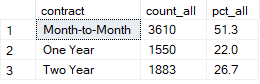

**Most of the customers are subscribed to the MTM contract (51%).**

Let's compare the above results for all the customers to San Diego's customers behavior:


```sql
-- pct of San Diego's customers by contract type

SELECT 
	contract,
	COUNT(*) AS count_sd,
		CAST(100.0 * COUNT(*) / SUM(COUNT(*)) OVER() AS DECIMAL(5,1)) AS pct_sd
FROM services AS serv
JOIN location AS loc
	ON serv.Customer_ID = loc.Customer_ID
WHERE city = 'San Diego'
GROUP BY contract;
```

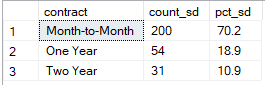

**San Diego’s customer population is heavily weighted toward Month-to-Month contracts (70% vs. 51% overall), meaning the city has far fewer ‘sticky’ long-term customers. This imbalance directly increases its churn vulnerability.**

**Churn Rate by Contract Comparison:**

```sql
-- churn rate by contract type for San Diego customers

SELECT 
	contract,
	COUNT(*) 
		AS total_customers_all,
    SUM(CASE WHEN customer_status IN (
		'Stayed', 'Churned') THEN 1 ELSE 0 END) 
		AS eligible_customers,
    SUM(CASE WHEN customer_status = 'Churned' THEN 1 END) 
		AS churned,
	CAST(100.0 * SUM(CASE WHEN churn_value = 1 THEN 1 END) 
		/ NULLIF(
			SUM(CASE WHEN customer_status IN (
			'Stayed', 'Churned') THEN 1 ELSE 0 END),0) 
			AS DECIMAL(5,1)
	) AS churn_rate
FROM services AS serv
JOIN location AS loc
	ON serv.Customer_ID = loc.Customer_ID
JOIN status AS stat
	ON stat.Customer_ID = loc.Customer_ID
WHERE city = 'San Diego'
GROUP BY contract;
```
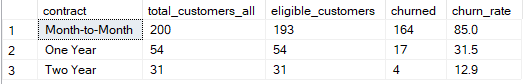

```sql
-- churn rate by contract type

SELECT 
	contract,
	COUNT(*) 
		AS total_customers_all,
    SUM(CASE WHEN customer_status IN (
		'Stayed', 'Churned') THEN 1 ELSE 0 END) 
		AS eligible_customers,
    SUM(CASE WHEN customer_status = 'Churned' THEN 1 END) 
		AS churned,
	CAST(100.0 * SUM(CASE WHEN churn_value = 1 THEN 1 END) 
		/ NULLIF(
			SUM(CASE WHEN customer_status IN (
			'Stayed', 'Churned') THEN 1 ELSE 0 END),0) 
			AS DECIMAL(5,1)
	) AS churn_rate
FROM services AS serv
JOIN location AS loc
	ON serv.Customer_ID = loc.Customer_ID
JOIN status AS stat
	ON stat.Customer_ID = loc.Customer_ID
GROUP BY contract;
```
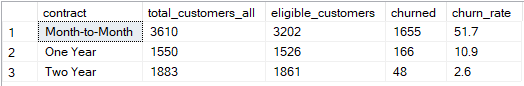

Month-to-Month contracts have the highest churn overall at 45.8%, but in San Diego, the churn for the same contract type is dramatically higher at 82%. One Year and Two Year contracts maintain low churn both overall (10.7% and 2.5%) and in San Diego (31.5% and 12.9%), though SD rates are slightly elevated. This comparison shows that San Diego’s extremely high churn is driven not only by its large proportion of Month-to-Month customers but also by the fact that these customers are much more likely to churn than Month-to-Month customers elsewhere. 

**Retention strategies in San Diego should therefore focus on converting Month-to-Month customers to longer-term contracts and addressing the factors behind their unusually high churn.**

**Monthly Charges Comparison:**

```sql
-- avg monthly charges & max/min charges by contract for San Diego customers

SELECT 
    contract,
    ROUND(AVG(Monthly_Charge),1) AS avg_monthly_charges,
    ROUND(MIN(Monthly_Charge),1) AS min_charge,
    ROUND(MAX(Monthly_Charge),1) AS max_charge
FROM services AS serv
JOIN location AS loc
    ON serv.Customer_ID = loc.Customer_ID
WHERE city = 'San Diego'
GROUP BY contract;

-- avg monthly charges & max/min charges by contract

SELECT 
    contract,
    ROUND(AVG(Monthly_Charge),1) AS avg_monthly_charges,
    ROUND(MIN(Monthly_Charge),1) AS min_charge,
    ROUND(MAX(Monthly_Charge),1) AS max_charge
FROM services AS serv
JOIN location AS loc
    ON serv.Customer_ID = loc.Customer_ID
GROUP BY contract;
```

**San Diego customers pay ~5% more on average for the same contract types, but this small price increase does not explain the city’s unusually high churn—especially among Month-to-Month customers.**

**Tenure Analysis:**

```sql
-- avg. tenure & median by contract type for San Diego customers

WITH TenureCTE AS (
    SELECT
        contract,
        tenure_in_months,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY tenure_in_months) 
            OVER (PARTITION BY contract) AS median_tenure
    FROM services AS serv
    JOIN location AS loc
        ON serv.Customer_ID = loc.Customer_ID
    WHERE loc.city = 'San Diego'
)
SELECT
    contract,
	CAST(AVG(tenure_in_months * 1.0) AS DECIMAL(5,1)) AS avg_tenure,
    MAX(median_tenure) AS median_tenure
FROM TenureCTE
GROUP BY contract
ORDER BY contract;
```
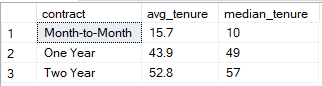

Generally, the newer the customer is the more likely they are to churn. San Diego’s elevated churn (66%) is strongly influenced by tenure length. Month-to-Month customers, who dominate San Diego's population, have a median tenure of only 10 months, indicating they are relatively new and highly prone to churn. Longer-term contract holders have much higher median tenure (49–57 months) and lower churn, but their smaller share of the population means they do not they don’t bring down the city’s overall churn. Therefore, **short tenure is a key factor driving San Diego’s high churn.**


## 3.3 Contract and Service Factors

After identifying high-churn patterns at the geographic level, the next step is to evaluate whether contract type and service offerings are contributing to customer churn. These factors directly influence customer stickiness, price sensitivity, and switching behavior.

Telco is offering a variety of services such as internet, phone lines, backup services, security services , premium technical support and unlimited data services. The company also offers different contract types: Month-to-Month, One Year and Two Year. 

### 3.3.1 Contract Type
As we have already seen on section 2.4, the MTM contract has the highest churn rate across all contract types.

In [3]:
%%HTML
<div class='tableauPlaceholder' id='viz1770548015528' style='position: relative'><noscript><a href='#'><img alt='Dashboard 8 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;ch&#47;churnratebycontractdb&#47;Dashboard8&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='churnratebycontractdb&#47;Dashboard8' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;ch&#47;churnratebycontractdb&#47;Dashboard8&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1770548015528');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='500px';vizElement.style.height='377px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='500px';vizElement.style.height='377px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

```sql
-- Average tenure by contract

SELECT
    Contract,
    CAST(
        AVG(CAST(tenure_in_months AS DECIMAL(10,4)))
        AS DECIMAL(5,1)
    ) AS avg_tenure
FROM Services
GROUP BY Contract;
```
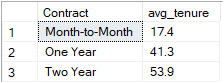

In [199]:
%%HTML
<div class='tableauPlaceholder' id='viz1765624664420' style='position: relative'><noscript><a href='#'><img alt='Avg. tenure by Contract (db) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Av&#47;Avg_tenurebyContractdb&#47;Avg_tenurebyContractdb&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Avg_tenurebyContractdb&#47;Avg_tenurebyContractdb' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Av&#47;Avg_tenurebyContractdb&#47;Avg_tenurebyContractdb&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1765624664420');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='300px';vizElement.style.height='427px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='300px';vizElement.style.height='427px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**As expected, the MTM contract has the lowest average tenure (17.4) whereas the two year contract has the highest average tenure (53.9) and the one year contract is right in the middle (41.3).**

* MTM has highest churn and shortest tenure → less “sticky”.
* Longer-term contracts have low churn and longer tenure → more “sticky”.

```sql
-- ARPM by contract type

SELECT
	contract,
	ROUND(AVG(monthly_charge),1) as avg_monthly_charges
FROM services
GROUP BY contract
ORDER BY avg_monthly_charges DESC;
```
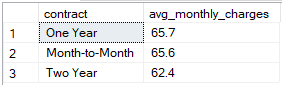

In [201]:
%%HTML
<div class='tableauPlaceholder' id='viz1765637687586' style='position: relative'><noscript><a href='#'><img alt='Avg Monthly Charges&#47;Contract (db) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Av&#47;Avg_MonthlyChargesbyContractdb&#47;AvgMonthlyChargesContractdb&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Avg_MonthlyChargesbyContractdb&#47;AvgMonthlyChargesContractdb' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Av&#47;Avg_MonthlyChargesbyContractdb&#47;AvgMonthlyChargesContractdb&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1765637687586');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='450px';vizElement.style.height='427px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='450px';vizElement.style.height='427px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**Despite significantly higher churn among Month-to-Month customers, their average monthly charges (65.6) are nearly identical to One-Year customers (65.7), indicating that higher churn is driven more by contract flexibility than by price differences.**

Here is a boxplot showcasing the distribution of average monthly charges across the different contract types:

In [10]:
%%HTML
<div class='tableauPlaceholder' id='viz1766062747179' style='position: relative'><noscript><a href='#'><img alt='Boxplot Mth. charges by Contract (db) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Mt&#47;Mth_ChargesboxplotbyContractdb&#47;BoxplotMth_chargesbyContractdb&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Mth_ChargesboxplotbyContractdb&#47;BoxplotMth_chargesbyContractdb' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Mt&#47;Mth_ChargesboxplotbyContractdb&#47;BoxplotMth_chargesbyContractdb&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1766062747179');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='600px';vizElement.style.height='527px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='600px';vizElement.style.height='527px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

Taking the MTM box as an example, if we look at the distance between Q1 and the median (71.1-45.3=25.8), and the distance between the median and Q3 (87.9-71.1=16.8), we can see that the assymetry is moderate (25.8-16.8=9).

All contracts are left-skewed which means:
- Among customers with higher monthly charges, prices are more standardized
- Among customers with lower monthly charges the prices spread across a wide range and there's no single typical price.

**In other words, for all contracts, there is more spread among lower charges and fewer extreme high ones.**

We’ll divide monthly charges into low, medium, and high tiers to examine their relationship with churn. For this, we will only focus on the MTM contract since it has the highest churn rate, and therefore, the highest impact on churn:

```sql
-- churn rate by contract and monthly charges group

	WITH q AS 
(
    SELECT
		serv.Customer_ID,
		serv.contract,
		serv.monthly_charge,
		stat.customer_status,
		PERCENTILE_CONT(0.25) -- generate the Q1 and Q3 values
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q1,
		PERCENTILE_CONT(0.75)
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q3
	FROM services AS serv
	JOIN status AS stat
    ON serv.Customer_ID = stat.Customer_ID

)
	SELECT
	  contract,
	  CASE -- create bins for low, mid and high monthly charges
		WHEN monthly_charge < q1 THEN 'low'
		WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
		ELSE 'high'
	  END AS mth_charges_group,
	  COUNT(*) AS total_customers,
	  SUM(CASE WHEN customer_status IN ('Churned', 'Stayed') THEN 1 ELSE 0 END) 
		AS eligible_customers,
	  CAST(100.0 * SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) / 
	  SUM(CASE WHEN customer_status IN ('Churned', 'Stayed') THEN 1 ELSE 0 END) 
		AS DECIMAL(5,1)) AS churn_rate
	FROM q
	WHERE contract = 'Month-to-Month'
	GROUP BY
	  contract,
	  CASE
		WHEN monthly_charge < q1 THEN 'low'
		WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
		ELSE 'high'
	  END
	ORDER BY contract, churn_rate DESC;
```
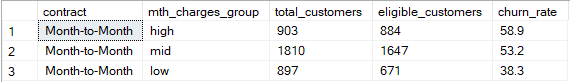

**Churn rate is highest in the high monthly charges tier, followed by medium, then low.** This tells us that the customers that are paying more are more likely to churn.

```sql
-- ARPM by contract (How much customers pay per month, pricing behavior)
-- Formula: ARPM = Total Revenue from Customer to Date / Number of Months Subscribed

SELECT 
  Contract,
  ROUND(SUM(Total_Revenue * 1.0) / SUM(Tenure_in_Months), 2) AS arpm
FROM services
GROUP BY Contract;
```
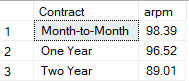

**Month-to-month customers generate higher revenue per active month, but typically churn sooner, while long-term contracts generate slightly lower monthly revenue but over a longer lifetime.**

```sql
-- average/median total revenue per customer by contract (How valuable customers are over time)
-- Formula: AVG Total Revenue = Total revenue from all customers in the segment / Total customers in the segment

WITH RevenueCTE AS
(
SELECT
	Contract,
	Total_revenue,
	PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY total_revenue) 
            OVER (PARTITION BY contract) AS median_total_revenue
FROM services
)
SELECT
    contract,
	CAST(AVG(total_revenue) AS DECIMAL(5,1)) AS avg_total_revenue,
    ROUND(MAX(total_revenue),1) AS median_total_revenue
FROM RevenueCTE
GROUP BY contract
ORDER BY median_total_revenue DESC, avg_total_revenue DESC;
```
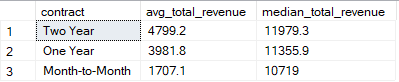

**Two-year contract customers generate the highest average lifetime revenue, while month-to-month customers generate the lowest. The typical customer across all contracts generates around $10k+ in lifetime revenue, with two-year contracts slightly higher than month-to-month.**

### 3.3.2 Tenure

```sql
-- Churn Rate by Tenure

WITH tenure_group_cte AS
(
SELECT
	CASE
          WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
          WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
          WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
          WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
          WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
          ELSE '61-72'
	END AS tenure_order,
    CASE
          WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
          WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
          WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
          WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
          WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
          ELSE '61-72'
    END AS tenure_group, customer_status
FROM Services AS serv
JOIN Status AS stat
ON serv.Customer_ID = stat.Customer_ID
)
SELECT 
	tenure_group,
	CAST(100.0 * SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) /
	COUNT(*) AS DECIMAL(5,1)) AS churn_rate
FROM tenure_group_cte
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY tenure_group, tenure_order
ORDER by tenure_order;
```
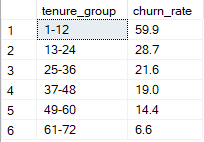

**There's a strong negative correlation between tenure and churn: customers with shorter tenure exhibit significantly higher churn rates.** 

However, it's important to check how churn behaves when including both tenure AND contract type, since we know that churn behaves differently in MTM versus fixed contracts:

```sql
-- Churn rate by contract type and tenure group

WITH tenure_group_cte AS
(
  SELECT
    CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN 1
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN 2
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN 3
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN 4
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN 5
      ELSE 6
    END AS tenure_order,
    CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
      ELSE '61-72'
    END AS tenure_group, Customer_Status, contract
  FROM Services AS serv
  JOIN Status AS stat
    ON serv.Customer_ID = stat.Customer_ID
),
rates AS
(
    SELECT 
		tenure_group,
        contract,
        CAST(
            ROUND(
                COUNT(CASE WHEN customer_status = 'Churned' THEN 1 END) * 100.0 / COUNT(*),
            1) 
        AS DECIMAL(5,1)) AS churn_rate_pct
    FROM tenure_group_cte
	WHERE Customer_Status IN ('Stayed', 'Churned')
    GROUP BY tenure_group, contract
)
SELECT *
FROM rates
PIVOT
(
    MAX(churn_rate_pct)
    FOR tenure_group IN
    (
        [1-12],
        [13-24],
		[25-36],
		[37-48],
		[49-60],
        [61-72]
    )
) piv
ORDER BY contract;
```
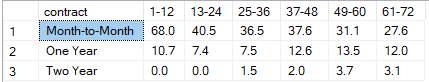

**MTM: the shorter the tenure the higher the churn rate.**

**Fixed contracts (one year, two year): the longer the tenure the higher the churn rate.**

MTM customers tend to churn more in general. By choosing a more flexible contract these customers don't expect to stay for a long time because they are always on a hunt to find a better offer. Fixed contract customers, on the other hand, sign a one year or two year contract because they want stability and the price/discount benefits that come with such contracts. Those customers are unlikely to churn early because it is harder to leave a fixed contracts as it involves early terminations fees and losing the benefits/discounts associated with the contract.

In [182]:
%%HTML
<div class='tableauPlaceholder' id='viz1769257431283' style='position: relative'><noscript><a href='#'><img alt='Churn rate by Tenure Group &amp; Contract Type (db) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ch&#47;Churnbytenuregroupcontractdb&#47;ChurnratebyTenureGroupContractTypedb&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Churnbytenuregroupcontractdb&#47;ChurnratebyTenureGroupContractTypedb' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ch&#47;Churnbytenuregroupcontractdb&#47;ChurnratebyTenureGroupContractTypedb&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1769257431283');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='600px';vizElement.style.height='577px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='600px';vizElement.style.height='577px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

```sql
-- Distribution of customers by Tenure
-- Using groups with equal amount of months (12) for a fair distribution display

WITH tenure_group_cte AS
(
  SELECT
    CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN 1
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN 2
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN 3
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN 4
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN 5
      ELSE 6
    END AS tenure_order,
    CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
      ELSE '61-72'
    END AS tenure_group,
    churn_value
  FROM Services AS serv
  JOIN Status AS stat
    ON serv.Customer_ID = stat.Customer_ID
)
SELECT 
  tenure_group,
  CAST(
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER()
    AS DECIMAL(5,1)
  ) AS pct_total_customers
FROM tenure_group_cte
GROUP BY tenure_group, tenure_order
ORDER BY tenure_order;

```
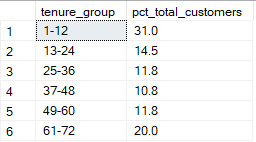

**Most customers are in their first year (31%), indicating strong acquisition but potentially high early churn. After year one, the distribution remains stable between 10–15% until year five, with 20% of customers in the 61–72 month range, demonstrating a substantial long-term customer base.**

In [86]:
%%HTML
<div class='tableauPlaceholder' id='viz1769256213041' style='position: relative'><noscript><a href='#'><img alt='Dashboard 7 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;CustomerCountbyTenureGroupdb&#47;Dashboard7&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='CustomerCountbyTenureGroupdb&#47;Dashboard7' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;CustomerCountbyTenureGroupdb&#47;Dashboard7&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1769256213041');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='550px';vizElement.style.height='577px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='550px';vizElement.style.height='577px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

```sql
-- ARPM by tenure group and contract type

WITH tenure_buckets AS (
    SELECT
        contract,
        monthly_charge,
        CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN 1
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN 2
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN 3
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN 4
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN 5
      ELSE 6
    END AS tenure_order,
    CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
      ELSE '61-72'
    END AS tenure_group
    FROM services
),
rates AS
(
SELECT
    contract,
	tenure_group,
    FLOOR(AVG(monthly_charge)) AS avg_monthly_charges
FROM tenure_buckets
WHERE tenure_group IS NOT NULL
GROUP BY contract, tenure_group
)
SELECT
*
FROM rates
PIVOT
(
    MAX(avg_monthly_charges)
    FOR tenure_group IN
    (
        [1-12],
        [13-24],
		[25-36],
		[37-48],
		[49-60],
        [61-72]
    )
) piv
ORDER BY contract;

```
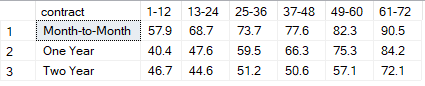

**Although average monthly charges are broadly similar across contract types, tenure-based analysis reveals that customers tend to increase their monthly spend over time. This indicates that revenue growth is driven more by customer lifecycle and service adoption than by contract structure alone.**

* Month-to-Month: Highest average monthly charges at every tenure level, with steady growth over time, but typically less stable due to higher churn risk.

* One-Year: Starts lower but shows consistent increases in monthly spend with tenure, reaching levels close to month-to-month for long-tenured customers.

* Two-Year: Lower monthly charges in early tenure, with gradual growth that pays off among long-tenured, high-retention customers.

In [103]:
%%HTML
<div class='tableauPlaceholder' id='viz1766320855738' style='position: relative'><noscript><a href='#'><img alt='Avg. Mth. charges by Tenure&#47;Contract (DB) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Av&#47;Avg_Mth_ChargesbyTenureLengthContractTypedb&#47;Avg_Mth_chargesbyTenureContractDB&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Avg_Mth_ChargesbyTenureLengthContractTypedb&#47;Avg_Mth_chargesbyTenureContractDB' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Av&#47;Avg_Mth_ChargesbyTenureLengthContractTypedb&#47;Avg_Mth_chargesbyTenureContractDB&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1766320855738');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='650px';vizElement.style.height='627px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='650px';vizElement.style.height='627px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

```sql
-- Avg. Total Revenue per Customer by Tenure

WITH tenure_group_cte AS
(
SELECT
	CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN 1
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN 2
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN 3
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN 4
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN 5
      ELSE 6
    END AS tenure_order,
    CASE
      WHEN tenure_in_months BETWEEN 1 AND 12 THEN '1-12'
      WHEN tenure_in_months BETWEEN 13 AND 24 THEN '13-24'
      WHEN tenure_in_months BETWEEN 25 AND 36 THEN '25-36'
      WHEN tenure_in_months BETWEEN 37 AND 48 THEN '37-48'
      WHEN tenure_in_months BETWEEN 49 AND 60 THEN '49-60'
      ELSE '61-72'
   END AS tenure_group, churn_value, total_revenue
FROM Services AS serv
JOIN Status AS stat
ON serv.Customer_ID = stat.Customer_ID
)
SELECT 
	tenure_group,
	ROUND(AVG(total_revenue),1) AS avg_total_revenue
FROM tenure_group_cte
GROUP BY tenure_group, tenure_order
ORDER BY tenure_order;
```
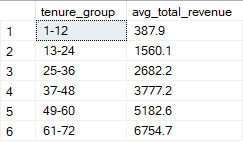

**As expected, average total revenue per customer increases with tenure, as customers who stay longer accumulate more months of subscription. This highlights the importance of retention, since longer customer lifespans generate significantly higher lifetime revenue.**

### 3.3.3 Pricing & Offers

```sql

-- Churn rate by monthly charges tiers
WITH q AS 
(
SELECT
	serv.Customer_ID,
	serv.contract,
	serv.monthly_charge,
	stat.customer_status,
	PERCENTILE_CONT(0.25) -- generate the Q1 and Q3 values
	WITHIN GROUP (ORDER BY serv.monthly_charge)
        OVER (PARTITION BY serv.contract) AS q1,
	PERCENTILE_CONT(0.75)
	WITHIN GROUP (ORDER BY serv.monthly_charge)
    	OVER (PARTITION BY serv.contract) AS q3
FROM services AS serv
JOIN status AS stat
ON serv.Customer_ID = stat.Customer_ID
WHERE stat.customer_status IN ('Stayed', 'Churned')
)
SELECT
	CASE -- create bins for low, mid and high monthly charges
    	WHEN monthly_charge < q1 THEN 'low'
		WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
		ELSE 'high'
	END AS mth_charges_group,
	COUNT(*) AS total_customers,
	SUM(CASE WHEN Customer_Status IN ('Stayed', 'Churned') THEN 1 ELSE 0 END) AS eligible_customers,
	CAST(
        SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*)
        AS DECIMAL(5,1)
    ) AS churn_rate
FROM q
GROUP BY
	CASE
    	WHEN monthly_charge < q1 THEN 'low'
    	WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
		ELSE 'high'
	END
ORDER BY churn_rate DESC;
```
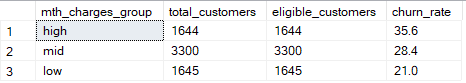

**The high-tier monthly charges group has the highest churn rate (36%) followed by the mid-tier (28%) and the low-tier group (21%). We can conlude that high monthly charge customers are higher-risk in terms of churn.**

```sql
--Churn rate by monthly charges tiers and contract type

WITH q AS 
(
    SELECT
		serv.Customer_ID,
		serv.contract,
		serv.monthly_charge,
		stat.customer_status,
		PERCENTILE_CONT(0.25) -- generate the Q1 and Q3 values
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q1,
		PERCENTILE_CONT(0.75)
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q3
	 FROM services AS serv
	 JOIN status AS stat
	ON serv.Customer_ID = stat.Customer_ID
	WHERE Customer_Status IN ('Stayed', 'Churned')	
),
tiers AS (
  SELECT
    Contract,
    customer_status,
    CASE
      WHEN monthly_charge < q1 THEN 'Low'
      WHEN monthly_charge < q3 THEN 'Mid'
      ELSE 'High'
    END AS mth_charges_group
  FROM q
)
SELECT
    Contract,
    mth_charges_group,
    COUNT(*) AS total_customers,
    CAST(100.0 * SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) / COUNT(*) AS DECIMAL(5,1)) AS churn_rate
FROM tiers
GROUP BY Contract, mth_charges_group
ORDER BY
    Contract,
    CASE mth_charges_group
        WHEN 'Low' THEN 1
        WHEN 'Mid' THEN 2
        WHEN 'High' THEN 3
    END;
```
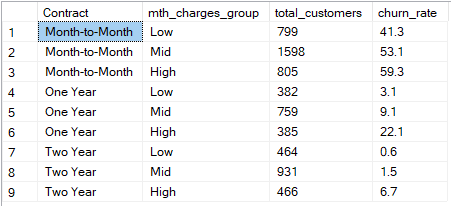

**While higher monthly charges are associated with increased churn within each contract type, churn rates differ far more dramatically across contract lengths, suggesting contract structure is a stronger indicator of churn risk than price level alone.**

```sql
-- Avg. Tenure by Monthly Charges

WITH q AS 
(
    SELECT
		serv.Customer_ID,
		serv.Tenure_in_months,
		serv.monthly_charge,
		stat.churn_value,
		PERCENTILE_CONT(0.25)
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q1,
		PERCENTILE_CONT(0.75)
		  WITHIN GROUP (ORDER BY serv.monthly_charge)
		  OVER (PARTITION BY serv.contract) AS q3
	FROM services AS serv
	JOIN status AS stat
	ON serv.Customer_ID = stat.Customer_ID
	WHERE Customer_Status IN ('Stayed', 'Churned')
),
tiers AS 
(
  SELECT
    Tenure_in_months,
    churn_value,
    CASE
      WHEN monthly_charge < q1 THEN 'low'
      WHEN monthly_charge < q3 THEN 'mid'
      ELSE 'high'
    END AS mth_charges_group
  FROM q
)
SELECT 
	mth_charges_group,
	AVG(Tenure_in_months) AS avg_tenure
FROM tiers
GROUP BY mth_charges_group
ORDER BY
	CASE mth_charges_group
		WHEN 'low' THEN 1 
		WHEN 'mid' THEN 2
		WHEN 'high' THEN 3
	END;
```
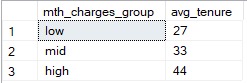

**The low monthly charges tier has the shortest average tenure of 44 months, followed by the mid tier with a longer average tenure of 33 months, and the high tier with an even longer average tenure of 44 months.** This confirms that customers who have been with the company for less time are paying smaller prices compared to customers who have been with the company for a significantly longer time. 

Reasons for this behavior could be:

- Time-related price inflation where services and features may increase over time.
- Upgrades they have done to their plan throughout their tenure.
- Changes in contract type where annual contracts tend to include more services, and monthly contracts that tend to have a basic cheaper plan.
- Loyal customers who stayed longer are more engaged and tend to reach for more pricey plans.

```sql
-- churn rate by refund buckets

WITH	
	refund_buckets AS
(
SELECT
	CASE
		WHEN total_refunds = 0 THEN 1
		WHEN total_refunds > 0 AND total_refunds <= 10 THEN 2
		WHEN total_refunds > 10 AND total_refunds <= 25 THEN 3
		ELSE 4
	END AS refund_order,
	CASE
		WHEN total_refunds = 0 THEN '0'
		WHEN total_refunds > 0 AND total_refunds <= 10 THEN '0–10'
		WHEN total_refunds > 10 AND total_refunds <= 25 THEN '10–25'
		ELSE '25–49'
	END AS refund_bucket, customer_status
FROM services
JOIN status
ON services.Customer_ID = status.Customer_ID
)
SELECT
	refund_bucket,
	CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END)
		* 100.0 / COUNT(*) 
		AS DECIMAL(5,1)
	) AS churn_rate
FROM refund_buckets
GROUP BY refund_bucket, refund_order
ORDER BY refund_order;
```
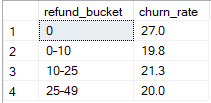

**Refund amount does not show a strong relationship with churn. Churn rates remain relatively stable across refund levels, suggesting that small billing refunds in this dataset are not a reliable indicator of customer dissatisfaction or churn risk.**

### 3.3.4 Churn Category/Reason

```sql
-- churn pct by category = churned in category / total churned customers
SELECT
	churn_category,
	CAST(
		100.0 *
		COUNT(*) / (SELECT COUNT(*) FROM status WHERE churn_value = 1)
		AS DECIMAL(5,1)
	) AS pct_of_total_churn
FROM status
WHERE churn_value = 1
GROUP BY churn_category
ORDER BY pct_of_total_churn DESC;
```
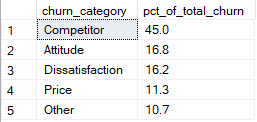

**Almost half (45%) of the customers who churned left because of competitor-related reasons.** 

In [20]:
%%HTML
<div class='tableauPlaceholder' id='viz1767456235388' style='position: relative'><noscript><a href='#'><img alt='% of Total Churn by Category (db) ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;of&#47;ofTotalChurnbyCategorydb&#47;ofTotalChurnbyCategorydb&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='ofTotalChurnbyCategorydb&#47;ofTotalChurnbyCategorydb' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;of&#47;ofTotalChurnbyCategorydb&#47;ofTotalChurnbyCategorydb&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1767456235388');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='700px';vizElement.style.height='587px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='700px';vizElement.style.height='587px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

```sql
-- pct of total churn by category & contract

WITH pct_total_churn_cte AS
(
    SELECT
        serv.contract,
        st.churn_category,
        CAST(
			COUNT(*) * 100.0 / SUM(COUNT(*)) OVER 
			(PARTITION BY serv.contract) AS DECIMAL(5,1)
		) AS pct_total_churn
    FROM status AS st
    JOIN services AS serv
      ON st.Customer_ID = serv.Customer_ID
    WHERE st.churn_category IS NOT NULL
    GROUP BY serv.contract, st.churn_category
)
SELECT *
FROM pct_total_churn_cte
PIVOT
(
    SUM(pct_total_churn)
    FOR churn_category IN ([Competitor], [Attitude], [Dissatisfaction], [Price], [Other])
) piv;
```
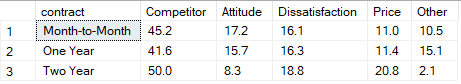

**Across all contract types, competitor-related churn reasons account for the highest share of churn. We can also see that in both the MTM and the One Year contracts, the price category is around 11% churn rate, but the Two Year contract has a higher churn rate of 20%. This indicates that long-tenure customers may have lower tolerance for price increases, even when their absolute monthly charges are relatively low.**

In [24]:
%%HTML
<div class='tableauPlaceholder' id='viz1767516716919' style='position: relative'><noscript><a href='#'><img alt='Dashboard 6 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;of&#47;ofTotalChurnbyContractCategorydb&#47;Dashboard6&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='ofTotalChurnbyContractCategorydb&#47;Dashboard6' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;of&#47;ofTotalChurnbyContractCategorydb&#47;Dashboard6&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1767516716919');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='700px';vizElement.style.height='567px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='700px';vizElement.style.height='567px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

```sql
-- pct of total churn by churn reason

SELECT
	churn_reason,
	CAST(
		100.0 *
		COUNT(*) / (SELECT COUNT(*) FROM status WHERE churn_value = 1)
		AS DECIMAL(5,1)
	) AS pct_of_total_churn
FROM status
WHERE churn_value = 1
GROUP BY churn_reason
ORDER BY pct_of_total_churn DESC;
```
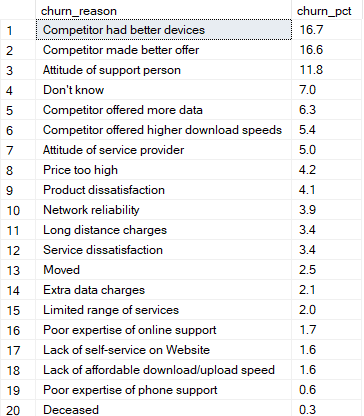

**The top 3 churn reasons are 'Competitor had better devices', 'Competitor made better offer' and 'Attitude of support person'. This aligns with the top churn categories 'Competitor' and 'Attitude'.**

### 3.3.5 Referral Behavior

```sql
-- % of customers who referred at least one friend

SELECT
	CASE
		WHEN Referred_a_Friend = 0 THEN 'No' ELSE 'Yes' 
	END AS referral_status,
	CAST(
		COUNT (*) * 100.0 / SUM(COUNT(*)) OVER () 
		AS DECIMAL(5,1)
	) AS pct_total_customers
FROM services
GROUP BY Referred_a_Friend;
```
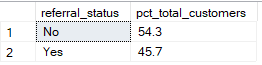

**Approximately 46% of customers have referred at least one friend, indicating that referral behavior is relatively common across the customer base.**

```sql
-- Churn rate by referral status

SELECT
    CASE 
        WHEN referred_a_friend = 1 THEN 'Yes' ELSE 'No' 
    END AS referral_status,
    CAST(
        SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*) AS DECIMAL(5,1)
    ) AS churn_rate
FROM services s
JOIN status st 
ON s.Customer_ID = st.Customer_ID
WHERE customer_status IN ('Churned', 'Stayed')
GROUP BY referred_a_friend;
```
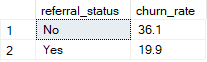

**Customers who have referred at least one friend exhibit significantly lower churn rates (19.9%) compared to non-referring customers (36.1%), highlighting referral behavior as a strong indicator of customer loyalty.**

```sql
-- % of referring customers by contract

SELECT
	Contract,
	CAST(
		100.0 * COUNT(*) / SUM(COUNT(*)) OVER () 
		AS DECIMAL(5,1)
	) AS pct_referring_customers
FROM services
WHERE Referred_a_Friend = 1
GROUP BY Contract;
```
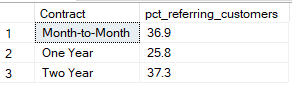

**Referral incidence is highest among two-year contract customers, indicating stronger advocacy among long-term subscribers. Month-to-month customers also demonstrate relatively high referral rates, potentially driven by early engagement, while one-year customers show lower referral activity.**

```sql
-- Churn rate by referral buckets

WITH referral_buckets AS
(
SELECT
	CASE
	  WHEN number_of_referrals = 0 THEN '0'
	  WHEN number_of_referrals = 1 THEN '1'
	  WHEN number_of_referrals BETWEEN 2 AND 3 THEN '2–3'
	  ELSE '4+'
	END AS referral_bucket, customer_status
FROM services
JOIN status 
ON services.Customer_ID = status.Customer_ID
WHERE customer_status IN ('Churned', 'Stayed')
)
SELECT
	referral_bucket,
		CAST(
			SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
			* 100.0 / COUNT(*)
			AS DECIMAL(5,1)
		) AS churn_rate
FROM referral_buckets
GROUP BY referral_bucket
ORDER BY referral_bucket;
```
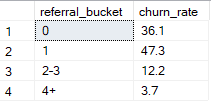

**Churn rates vary non-linearly with referral behavior. Customers who made exactly one referral exhibit the highest churn rate, exceeding even customers who made no referrals. In contrast, customers who made two or more referrals show substantially lower churn. This indicates that repeated referral behavior is associated with strong, sustained loyalty, while a single referral may reflect a situational or short-term action rather than long-term retention.**

In [11]:
%%HTML
<div class='tableauPlaceholder' id='viz1768503960397' style='position: relative'><noscript><a href='#'><img alt='Dashboard 12 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ch&#47;ChurnRatebyReferralStatusbucketsDB&#47;Dashboard12&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='ChurnRatebyReferralStatusbucketsDB&#47;Dashboard12' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ch&#47;ChurnRatebyReferralStatusbucketsDB&#47;Dashboard12&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1768503960397');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='600px';vizElement.style.height='527px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='600px';vizElement.style.height='527px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

### 3.3.6 Internet Service

```sql
-- churn rate by internet type + monthly charge tier

WITH 
	q AS (
		SELECT
			services.Internet_Type,
			services.Monthly_charge,
			status.Customer_status,
			PERCENTILE_CONT(0.25) -- generate the Q1 and Q3 values
				  WITHIN GROUP (ORDER BY monthly_charge)
				  OVER (PARTITION BY contract) AS q1,
				PERCENTILE_CONT(0.75)
				  WITHIN GROUP (ORDER BY monthly_charge)
				  OVER (PARTITION BY contract) AS q3
		FROM services
		JOIN status
		ON services.Customer_ID = status.Customer_ID
		WHERE Customer_Status IN ('Stayed', 'Churned')
		AND Internet_Service = 1
), 
	rates AS (
		SELECT 
			Internet_type,
			CAST(
				SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) * 100.0
				/ COUNT(*) AS DECIMAL(5,1)
			) AS churn_rate,
			CASE
				WHEN monthly_charge < q1 THEN 'low'
				WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
				ELSE 'high'
			  END AS mth_charges_group
		FROM q
		GROUP BY
			CASE
				WHEN monthly_charge < q1 THEN 'low'
				WHEN monthly_charge BETWEEN q1 AND q3 THEN 'mid'
				ELSE 'high'
			  END, Internet_Type
)
SELECT
	*
FROM rates
PIVOT (
    MAX(churn_rate)
    FOR mth_charges_group IN ([low], [mid], [high])
) AS piv;
```
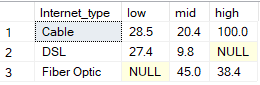

Churn behavior differs strongly by both internet type and price tier:
* Cable churn is highest in the low price bucket (28.5%) and lowest in the mid bucket (20.4%), while the high bucket shows 100% churn, indicating very few customers in that segment.
* DSL churn is low in the mid bucket (9.8%) and higher in the low bucket (27.4%), with no customers in the high bucket.
* Fiber Optic churn is highest in the mid price tier (45.0%), and there are no low-price Fiber customers, while high-price Fiber churn is 38.4%.

**This suggests that churn is not only influenced by internet type but also by price sensitivity, and that Fiber customers are most at risk in the mid-price tier.**

The results show 100% churn for the high-price Cable segment. Let's check the customer distribution for each group to see whether this particular group has a very small sample (very likely) since having 100% churn rate with a big sample is quite rare:

```sql

WITH q AS (
    SELECT
        s.Internet_Type,
        s.Monthly_charge,
        PERCENTILE_CONT(0.25) 
            WITHIN GROUP (ORDER BY s.Monthly_charge)
            OVER (PARTITION BY s.contract) AS q1,
        PERCENTILE_CONT(0.75)
            WITHIN GROUP (ORDER BY s.Monthly_charge)
            OVER (PARTITION BY s.contract) AS q3
    FROM services s
    JOIN status st
        ON s.Customer_ID = st.Customer_ID
    WHERE st.Customer_Status IN ('Stayed', 'Churned')
      AND s.Internet_Service = 1
)
SELECT
    Internet_Type,
    CASE
        WHEN Monthly_charge < q1 THEN 'low'
        WHEN Monthly_charge BETWEEN q1 AND q3 THEN 'mid'
        ELSE 'high'
    END AS mth_charges_group,
    COUNT(*) AS customers
FROM q
GROUP BY
    Internet_Type,
    CASE
        WHEN Monthly_charge < q1 THEN 'low'
        WHEN Monthly_charge BETWEEN q1 AND q3 THEN 'mid'
        ELSE 'high'
    END
ORDER BY Internet_Type, mth_charges_group;
```

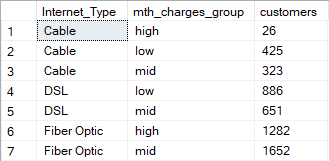

**As suspected, the high-price Cable segment consists of only 26 customers, which makes the observed 100% churn rate less reliable and likely driven by the very small sample size.**

```sql
-- churn rate by internet type & contract

WITH 
	c_rate AS (
		SELECT
			CAST(
				SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) * 100.0
				/ COUNT(*) AS DECIMAL(5,1)
			) AS churn_rate,
			services.Contract,
			services.Internet_Type
		FROM services
		JOIN status
			ON services.Customer_ID = status.Customer_ID
		WHERE Customer_Status IN ('Stayed', 'Churned')
		AND Internet_Service = 1
		GROUP BY Contract, Internet_Type
)
SELECT
	*
FROM c_rate
PIVOT (
    MAX(churn_rate)
    FOR Contract IN (
		[Month-to-month],
		[One Year],
		[Two Year]
	)
) AS piv;
```
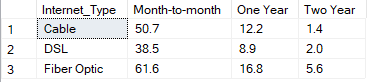

```sql
-- Churn rate by Internet Type + Referral Status

WITH 
	c_rate AS
(
		SELECT 
			Internet_type,
			CASE 
				WHEN Referred_a_friend = 1 THEN 'Yes' 
				ELSE 'No' 
				END AS referred_label,
			CAST(
			SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
			* 100.0 / COUNT(*)
			AS DECIMAL(5,1)
		) AS churn_rate
		FROM
		services
		JOIN status
		ON services.Customer_ID=status.Customer_ID
		WHERE Customer_Status IN ('Churned', 'Stayed')
		GROUP BY Internet_Type, Referred_a_Friend
)
SELECT
	*
FROM
c_rate
PIVOT (
	SUM(churn_rate) 
	FOR referred_label IN (
		[Yes],
		[No]
	)
) piv;
```
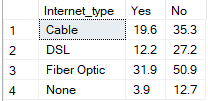

- Customers who did NOT refer a friend have a much higher churn rate.
- Customers who did refer a friend have a lower churn rate.

**Therefore, we can conclude that referral behavior is strongly associated with lower churn.** Knowing this Telco can target non-referrers with retention campaigns.

```sql
-- Churn rate by Internet Type + Customer Tenure Bucket

WITH tenure_grouping AS
(
	SELECT
		Internet_Type,
		CASE
			WHEN Tenure_in_Months BETWEEN 0 AND 6 THEN '0-6'
			WHEN Tenure_in_Months BETWEEN 7 AND 12 THEN '7-12'
			ELSE '12+'
		END AS tenure_group,
		customer_status
	FROM services
	JOIN status
	ON services.Customer_ID = status.Customer_ID
), c_rate AS
(
SELECT
	Internet_Type,
	tenure_group,
	CAST(
		100.0 * SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END)
		/ COUNT(*) AS DECIMAL(5,1)
	) AS churn_rate
FROM tenure_grouping
WHERE customer_status IN ('Stayed', 'Churned')
    AND Internet_Type <> 'None'
GROUP BY Internet_Type, tenure_group
)
SELECT 
	*
FROM c_rate
PIVOT
(
	SUM(churn_rate)
	FOR tenure_group IN (
		[0-6],
		[7-12],
		[12+]
	)
) piv;

```
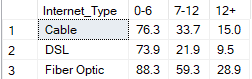

### 3.3.7 Add-ons

```sql

-- ARPM and Average Tenure by Streaming TV (Yes/No)

SELECT
    CASE
		WHEN Streaming_TV = 1 THEN 'Yes' 
		ELSE 'No' 
	END AS Streaming_TV,
    ROUND(AVG(monthly_charge),1) AS avg_monthly_charge,
    AVG(tenure_in_months) AS avg_tenure,
    CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) 
		AS DECIMAL(5,1)
	) AS churn_rate
FROM services
JOIN status
ON services.Customer_ID = status.Customer_ID
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY streaming_tv;
```
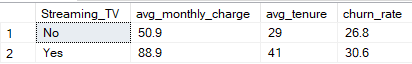

```sql
-- ARPM and Average Tenure by Streaming Movies (Yes/No)

SELECT
    CASE
		WHEN Streaming_Movies = 1 THEN 'Yes' 
		ELSE 'No' 
	END AS Streaming_Movies,
    ROUND(AVG(monthly_charge),1) AS avg_monthly_charge,
    AVG(tenure_in_months) AS avg_tenure,
    CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) 
		AS DECIMAL(5,1)
	) AS churn_rate
FROM services
JOIN status
ON services.Customer_ID = status.Customer_ID
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY Streaming_Movies;
```
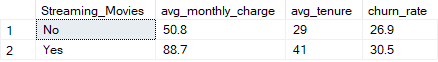

```sql
-- ARPM and Average Tenure by Streaming Music (Yes/No)

SELECT
    CASE
		WHEN Streaming_Music= 1 THEN 'Yes' 
		ELSE 'No' 
	END AS Streaming_Music,
    ROUND(AVG(monthly_charge),1) AS avg_monthly_charge,
    AVG(tenure_in_months) AS avg_tenure,
    CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) 
		AS DECIMAL(5,1)
	) AS churn_rate
FROM services
JOIN status
ON services.Customer_ID = status.Customer_ID
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY Streaming_Music;
```
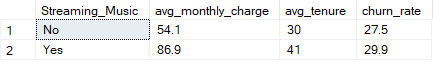

**Across all streaming add-ons (TV, Movies, Music), customers show the same pattern: higher average monthly revenue and longer tenure, alongside slightly higher churn rates. This indicates that add-ons increase customer value and longevity, but do not fully prevent churn over the customer lifecycle.**

```sql
-- Churn Rate, ARPM, and Average Tenure by Premium Tech Support (Yes/No)

SELECT 
	CASE 
		WHEN Premium_Tech_Support = 0 THEN 'No'
		ELSE 'Yes'
	END AS Premium_Tech_Support,
    ROUND(AVG(monthly_charge),1) AS avg_monthly_charge,
    AVG(tenure_in_months) AS avg_tenure,
	CAST(
		SUM(
		CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) 
		AS DECIMAL(5,1)
	) AS churn_rate
FROM services
JOIN status
ON services.Customer_ID = status.Customer_ID
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY Premium_Tech_Support;
```
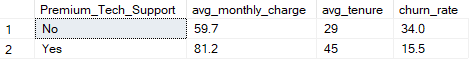

**Customers with Premium Tech Support have significantly higher monthly revenue (ARPM of 81.2 vs 59.7) and much longer tenure (45 vs 29 months), while also showing substantially lower churn (15.5% vs 34.0%). This indicates that Premium Tech Support is associated with both higher customer value and stronger retention, making it a key lever for reducing churn and increasing long-term revenue.**

```sql
-- Churn Rate, ARPM, and Average Tenure by line type

SELECT
    CASE 
        WHEN multiple_lines = 1 THEN 'Multiple Lines'
        ELSE 'Single Line'
    END AS line_type,
	ROUND(AVG(monthly_charge),1) AS avg_monthly_charge,
    AVG(tenure_in_months) AS avg_tenure,
    CAST(
        100.0 * SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
        / COUNT(*) 
        AS DECIMAL(5,1)
    ) AS churn_rate
FROM services
JOIN status
ON services.Customer_ID = status.Customer_ID
WHERE customer_status IN ('Stayed', 'Churned')
GROUP BY multiple_lines;
```
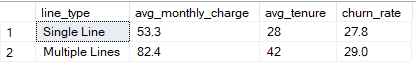

**Multi-line customers pay more and stay longer, likely because they are families or businesses with higher switching costs, but their churn is slightly higher, possibly due to price sensitivity or competitive offers.**

```sql
-- Churn Rate, ARPM, and Average Tenure by internet usage

WITH 
	usage_buckets AS
(
SELECT
	CASE
		WHEN Avg_Monthly_GB_Download = 0 THEN 1
		WHEN Avg_Monthly_GB_Download > 0 AND Avg_Monthly_GB_Download <= 10 THEN 2
		WHEN Avg_Monthly_GB_Download > 10 AND Avg_Monthly_GB_Download <= 30 THEN 3
		WHEN Avg_Monthly_GB_Download > 30 AND Avg_Monthly_GB_Download <= 60 THEN 4
		ELSE 5
	END AS usage_order,
	CASE
		WHEN Avg_Monthly_GB_Download = 0 THEN '0 GB (No Usage)'
		WHEN Avg_Monthly_GB_Download > 0 AND Avg_Monthly_GB_Download <= 10 THEN '0–10 GB'
		WHEN Avg_Monthly_GB_Download > 10 AND Avg_Monthly_GB_Download <= 30 THEN '10–30 GB'
		WHEN Avg_Monthly_GB_Download > 30 AND Avg_Monthly_GB_Download <= 60 THEN '30–60 GB'
		ELSE '60+ GB'
	END AS usage_bucket, 
	customer_status,
	monthly_charge,
	tenure_in_months
FROM services 
JOIN status
ON services.Customer_ID = status.Customer_ID
)
SELECT
	usage_bucket,
	ROUND(AVG(monthly_charge),1) AS avg_monthly_charge,
    AVG(tenure_in_months) AS avg_tenure,
	CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*)
		AS DECIMAL(5,1)
	) AS churn_rate
FROM usage_buckets
GROUP BY usage_bucket,usage_order
ORDER BY usage_order;
```
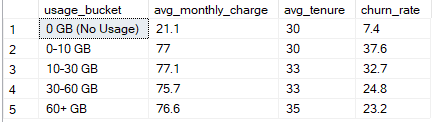

**Churn is lowest among non-internet customers and highest among light-usage customers. While average monthly revenue is similar across most usage levels, churn decreases as internet usage increases, suggesting that engagement and dependency on the service — rather than price — are the primary drivers of retention. Light users represent the most at-risk segment for churn.**

## 3.4 Predictive & Derived Metrics

### 3.4.1 Churn Score

```sql
-- customer distribution by churn score

WITH CTE AS
(
    SELECT
        contract,
        churn_score,
        COUNT(*) AS customer_count
    FROM status
    JOIN services 
      ON status.Customer_ID = services.Customer_ID
    GROUP BY churn_score, contract
)
SELECT
    churn_score,
    COALESCE([Month-to-Month], 0) AS [Month-to-Month],
    COALESCE([One Year], 0)       AS [One Year],
    COALESCE([Two Year], 0)       AS [Two Year]
FROM CTE
PIVOT
(
    SUM(customer_count)
    FOR contract IN ([Month-to-Month], [One Year], [Two Year])
) piv
ORDER BY churn_score;
```
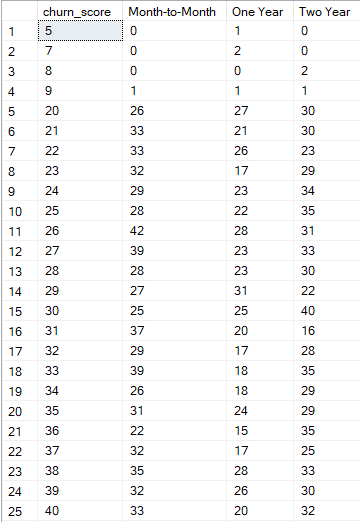
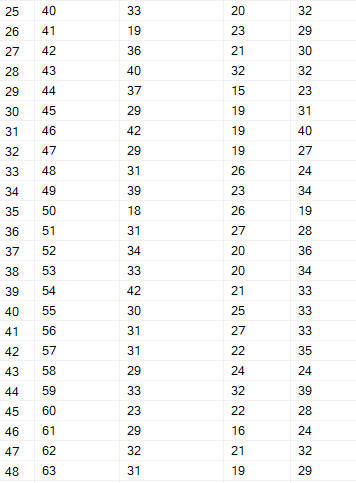
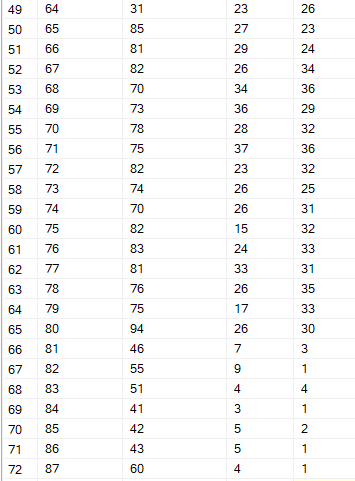
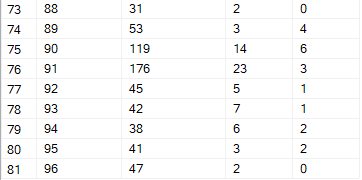

In [1]:
%%HTML
<div class='tableauPlaceholder' id='viz1767790597761' style='position: relative'><noscript><a href='#'><img alt='Dashboard 11 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;CustomerCountbyChurnScoreDB&#47;Dashboard11&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='CustomerCountbyChurnScoreDB&#47;Dashboard11' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;CustomerCountbyChurnScoreDB&#47;Dashboard11&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1767790597761');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='800px';vizElement.style.height='587px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='800px';vizElement.style.height='587px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**The churn score distribution is skewed toward mid-to-high values, with relatively few customers at the extreme low or high ends.**

```sql
-- Customer distribution by churn score bucket

WITH churn_score_buckets AS
(
    SELECT
        CASE
            WHEN churn_score BETWEEN 0 AND 20 THEN '0–20'
            WHEN churn_score BETWEEN 21 AND 40 THEN '21–40'
            WHEN churn_score BETWEEN 41 AND 60 THEN '41–60'
            WHEN churn_score BETWEEN 61 AND 80 THEN '61–80'
            ELSE '81–100'
        END AS churn_score_bucket
    FROM status
)
SELECT 
	churn_score_bucket,
	COUNT(*) AS total_customers
FROM churn_score_buckets
GROUP BY churn_score_bucket
ORDER BY churn_score_bucket;
```
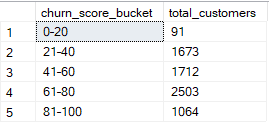

**The largest customer segment falls within the 61–80 churn score bucket, indicating elevated overall churn risk. Although customers with very high churn scores (81–100) represent a smaller portion of the base, they are clear candidates for immediate retention interventions.**

```sql
-- churn rate by churn score buckets

WITH churn_score_buckets AS
(
    SELECT
        CASE
            WHEN churn_score BETWEEN 0 AND 20 THEN '0–20'
            WHEN churn_score BETWEEN 21 AND 40 THEN '21–40'
            WHEN churn_score BETWEEN 41 AND 60 THEN '41–60'
            WHEN churn_score BETWEEN 61 AND 80 THEN '61–80'
            ELSE '81–100'
        END AS churn_score_bucket,
        customer_status
    FROM status
)
SELECT
    churn_score_bucket,
    CAST(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER ()
        AS DECIMAL(5,1)
    ) AS customer_pct,
    CAST(
        SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) * 100.0
        /
        NULLIF(
            SUM(CASE WHEN customer_status IN ('Churned','Stayed') THEN 1 ELSE 0 END),
            0
        )
        AS DECIMAL(5,1)
    ) AS churn_rate
FROM churn_score_buckets
GROUP BY churn_score_bucket
ORDER BY churn_score_bucket;
```
NOTE: churn score represents [a value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset/data)

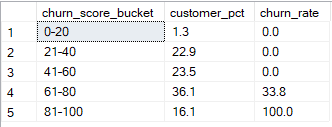
 
**The churn score distribution shows a clear separation between low-risk and high-risk customers, confirming that the predictive model is functioning as intended.**

- Low-risk segments (0–60) account for ~48% of the customer base and show 0% observed churn, indicating strong retention and low immediate risk.

- Mid-to-high risk customers (61–80) represent the largest segment (36.1%), with a churn rate of 33.8%, making this group the most impactful target for proactive retention efforts.

- Very high-risk customers (81–100) make up 16.1% of customers, with 100% churn, suggesting these customers are already effectively lost or churn-committed.

### 3.4.2 Satisfaction Score

```sql
-- churn rate by satisfaction score

SELECT
    satisfaction_score,
	CAST(
		100.0 * COUNT(*) / SUM(COUNT(*)) OVER () 
		AS DECIMAL(5,1)
	) AS total_customers,
    CAST(SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*) AS DECIMAL(5,1)) 
	AS churn_rate
FROM status
WHERE customer_status IN ('Churned', 'Stayed')
GROUP BY satisfaction_score
ORDER BY satisfaction_score;
```
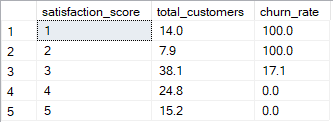

**While customers with low satisfaction scores (1–2) exhibit the highest churn rates, the majority of the customer base reports a satisfaction score of 3. This mid-tier group represents a critical segment: although not highly dissatisfied, these customers are not fully satisfied and may be susceptible to churn if their concerns are not addressed. As a result, retention efforts should not focus solely on extreme dissatisfaction, but also on improving the experience of moderately satisfied customers.**

### 3.4.3 CLTV

```sql
-- churn rate by CLTV tier
-- tier 1 = lowest cltv, tier 4 = highest cltv

WITH cltv AS
(
SELECT
	CASE NTILE(4) OVER (ORDER BY cltv) 
		WHEN 1 THEN 'Tier 1'
        WHEN 2 THEN 'Tier 2'
        WHEN 3 THEN 'Tier 3'
		WHEN 4 THEN 'Tier 4'
    END AS cltv_tier, customer_status
FROM status
)
SELECT
	cltv_tier,
	CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) AS DECIMAL(5,1)) AS churn_rate
FROM cltv
WHERE Customer_Status IN ('Stayed', 'Churned')
GROUP BY cltv_tier
ORDER BY churn_rate DESC;
```
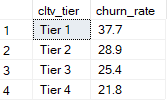

**Churn rates decline sharply across higher CLTV tiers, validating that predicted customer lifetime value effectively captures churn risk. This segmentation enables the business to differentiate retention strategies between low-value, high-risk customers and high-value customers where churn prevention yields the greatest return.**

```sql
-- CLTV by Customer Status (Median)

SELECT DISTINCT
    CASE 
        WHEN churn_value = 1 THEN 'Churned'
        ELSE 'Active'
    END AS customer_status,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY CLTV) 
        OVER (PARTITION BY churn_value) AS median_cltv
FROM status;
```
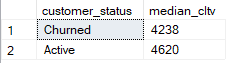

**The median CLTV of active customers (4620) is about 9% higher than that of churned customers (4238). This suggests that typical higher-value customers are slightly more likely to remain active, but the difference is relatively modest. Using the median gives a more representative view by reducing the influence of extreme high-value customers.**

```sql
-- Churn rate by contract type for high value customers (tier 4 cltv customers)

WITH cltv AS
(
SELECT
	CASE NTILE(4) OVER (ORDER BY cltv) 
		WHEN 1 THEN 'Tier 1'
        WHEN 2 THEN 'Tier 2'
        WHEN 3 THEN 'Tier 3'
		WHEN 4 THEN 'Tier 4'
    END AS cltv_tier, customer_status, Contract
FROM status
JOIN services 
ON status.Customer_ID = services.Customer_ID
)
SELECT 
	Contract,
	CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) AS DECIMAL(5,1)) AS churn_rate
FROM cltv
WHERE Customer_Status IN (
	'Stayed', 'Churned') 
AND cltv_tier = 'Tier 4'
GROUP BY Contract;
```
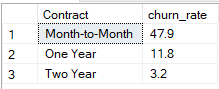

**Among top-tier CLTV customers, churn varies sharply by contract type. Month-to-Month customers exhibit a churn rate of 47.9%, indicating substantial retention risk even among the most valuable users. In contrast, One-Year and Two-Year contracts reduce churn to 11.8% and 3.2%, respectively, demonstrating that long-term contracts are highly effective at protecting high-value revenue.**

```sql
-- Churn rate by referral status for high value customers (tier 4 cltv customers)

WITH cltv AS
(
SELECT
	CASE NTILE(4) OVER (ORDER BY cltv) 
		WHEN 1 THEN 'Tier 1'
        WHEN 2 THEN 'Tier 2'
        WHEN 3 THEN 'Tier 3'
		WHEN 4 THEN 'Tier 4'
    END AS cltv_tier, customer_status, referred_a_friend
FROM status
JOIN services 
ON status.Customer_ID = services.Customer_ID
)
SELECT 
	CASE 
		WHEN referred_a_friend = 0 THEN 'No' ELSE 'Yes' 
		END AS referred_a_friend,
	CAST(
		SUM(CASE WHEN customer_status = 'Churned' THEN 1 ELSE 0 END) 
		* 100.0 / COUNT(*) AS DECIMAL(5,1)) AS churn_rate
FROM cltv
WHERE Customer_Status IN (
	'Stayed', 'Churned') 
AND cltv_tier = 'Tier 4'
GROUP BY referred_a_friend;
```
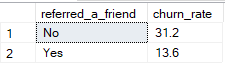

**Customers who refer friends churn less. Among Tier 4 customers, referrers churn at 13.6% vs 31.2% for non-referrers, showing that top-value customers who engage in referrals are particularly loyal.**